# Packages

In [120]:
import one_hot_encoder
%pip install sklearn
%pip install pandas
%pip install numpy
%pip install xgboost
%pip install matplotlib
%pip install seaborn
%pip install xgboost
%pip install cleanlab
%pip install ipywidgets
%pip install imbalanced-learn
%pip install statsmodels
%pip install shap
%pip install prophet
%pip install plotly
%pip install tensorflow
%pip install scipy


  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Preparing metadata (setup.py) ... error
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
    

# Imports

In [44]:
import glob
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from cleanlab.filter import find_label_issues
from imblearn.under_sampling import RandomUnderSampler
from matplotlib import cm
from sklearn.cluster import KMeans
from sklearn.decomposition import (
    PCA,
    TruncatedSVD
)
from sklearn.ensemble import IsolationForest, RandomForestClassifier, HistGradientBoostingRegressor
from sklearn.manifold import TSNE
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    auc,
    accuracy_score,
    mean_squared_error,
    mean_absolute_error,
    root_mean_squared_error
)
from sklearn.model_selection import (
    StratifiedKFold,
    TimeSeriesSplit,
    cross_val_predict,
    train_test_split
)
from sklearn.preprocessing import (
    MaxAbsScaler,
    MinMaxScaler,
    Normalizer,
    PowerTransformer,
    QuantileTransformer,
    RobustScaler,
    StandardScaler,
    minmax_scale,
    Binarizer,
    FunctionTransformer,
    OneHotEncoder
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stl.mstl import MSTL
import shap
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (SimpleRNN, LSTM, Conv1D,
                                     GlobalMaxPooling1D, Dense, Dropout)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate

# Functions

https://scikit-learn.org/stable/auto_examples/applications/plot_cyclical_feature_engineering.html#trigonometric-features

In [40]:
def sin_transformer(period):
    return FunctionTransformer(lambda x: np.sin(x / period * 2 * np.pi))


def cos_transformer(period):
    return FunctionTransformer(lambda x: np.cos(x / period * 2 * np.pi))

In [39]:
def evaluate(model, X, y, cv, model_prop=None, model_step=None):
    cv_results = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=["neg_mean_absolute_error", "neg_root_mean_squared_error"],
        return_estimator=model_prop is not None,
    )
    if model_prop is not None:
        if model_step is not None:
            values = [
                getattr(m[model_step], model_prop) for m in cv_results["estimator"]
            ]
        else:
            values = [getattr(m, model_prop) for m in cv_results["estimator"]]
        print(f"Mean model.{model_prop} = {np.mean(values)}")
    mae = -cv_results["test_neg_mean_absolute_error"]
    rmse = -cv_results["test_neg_root_mean_squared_error"]
    print(
        f"Mean Absolute Error:     {mae.mean():.3f} +/- {mae.std():.3f}\n"
        f"Root Mean Squared Error: {rmse.mean():.3f} +/- {rmse.std():.3f}"
    )

# Data Preprocessing

In [69]:
# Find all files that start with "PRSA_Data" and end with ".csv"
file_paths = glob.glob("./beijing+multi+site+air+quality+data/PRSA_Data_20130301-20170228/PRSA_Data_*.csv")

# Read all into a list
dataframes = [pd.read_csv(file) for file in file_paths]

# Combine them all together into one giant dataset
df_all = pd.concat(dataframes, ignore_index=True)

df_all['datetime'] = pd.to_datetime(df_all[['year', 'month', 'day', 'hour']])
df_all['DayOfWeek'] = df_all['datetime'].dt.dayofweek

# Create a binary feature: 1 if it is Saturday (5) or Sunday (6), 0 if weekday
df_all['Is_Weekend'] = (df_all['DayOfWeek'] >= 5).astype(int)

# Create a binary feature for "Rush Hour" (e.g., 7 AM to 9 AM, and 5 PM to 7 PM)
df_all['Is_Rush_Hour'] = df_all['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)

categorical_columns = df_all.columns[df_all.dtypes == "category"]

one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
cyclicTransformer = ColumnTransformer(
    transformers=[
        # ("categorical", one_hot_encoder, categorical_columns),
        ("month_sin", sin_transformer(12), ["month"]),
        ("month_cos", cos_transformer(12), ["month"]),
        ("weekday_sin", sin_transformer(7), ["DayOfWeek"]),
        ("weekday_cos", cos_transformer(7), ["DayOfWeek"]),
        ("hour_sin", sin_transformer(24), ["hour"]),
        ("hour_cos", cos_transformer(24), ["hour"]),
    ],
    remainder=MinMaxScaler(),
)

df_all['month_sin'] = np.sin(df_all['month'] / 12 * 2 * np.pi)
df_all['month_cos'] = np.cos(df_all['month'] / 12 * 2 * np.pi)
df_all['weekday_sin'] = np.sin(df_all['DayOfWeek'] / 7 * 2 * np.pi)
df_all['weekday_cos'] = np.cos(df_all['DayOfWeek'] / 7 * 2 * np.pi)
df_all['hour_sin'] = np.sin(df_all['hour'] / 24 * 2 * np.pi)
df_all['hour_cos'] = np.cos(df_all['hour'] / 24 * 2 * np.pi)

# Sort by station FIRST, then by time.
df_all = df_all.sort_values(by=['station', 'datetime']).reset_index(drop=True)

## Do we have missing data?

In [70]:
df_all.isnull().sum().sort_values(ascending=False)

CO              20701
O3              13277
NO2             12116
SO2              9021
PM2.5            8739
PM10             6449
wd               1822
DEWP              403
TEMP              398
PRES              393
RAIN              390
WSPM              318
Is_Weekend          0
weekday_sin         0
weekday_cos         0
month_cos           0
hour_sin            0
month_sin           0
Is_Rush_Hour        0
No                  0
DayOfWeek           0
datetime            0
station             0
year                0
hour                0
day                 0
month               0
hour_cos            0
dtype: int64

## Handling Missing Data - Forward-fill missing values

Forward fill and backward fill are methods used to handle missing values in time series data by propagating the last or next valid observation, respectively. These methods help maintain the continuity of observations in your dataset.

https://hatefdastour.github.io/notes/Introduction_to_Python_Programming/chapter_05/PyIntro_C05S07.html

In [71]:
df_all = (
    df_all
    .set_index('station')
    .groupby('station')
    .ffill()
    .bfill()
    .reset_index()
)

In [72]:
df_all.isnull().sum().sort_values(ascending=False)

station         0
No              0
hour_sin        0
weekday_cos     0
weekday_sin     0
month_cos       0
month_sin       0
Is_Rush_Hour    0
Is_Weekend      0
DayOfWeek       0
datetime        0
WSPM            0
wd              0
RAIN            0
DEWP            0
PRES            0
TEMP            0
O3              0
CO              0
NO2             0
SO2             0
PM10            0
PM2.5           0
hour            0
day             0
month           0
year            0
hour_cos        0
dtype: int64

In [73]:
df_all.columns.to_list()

['station',
 'No',
 'year',
 'month',
 'day',
 'hour',
 'PM2.5',
 'PM10',
 'SO2',
 'NO2',
 'CO',
 'O3',
 'TEMP',
 'PRES',
 'DEWP',
 'RAIN',
 'wd',
 'WSPM',
 'datetime',
 'DayOfWeek',
 'Is_Weekend',
 'Is_Rush_Hour',
 'month_sin',
 'month_cos',
 'weekday_sin',
 'weekday_cos',
 'hour_sin',
 'hour_cos']

In [74]:
df_all.describe().transpose()


,count,mean,min,25%,50%,75%,max,std
No,420768.0,17532.5,1.0,8766.75,17532.5,26298.25,35064.0,10122.116943
year,420768.0,2014.66256,2013.0,2014.0,2015.0,2016.0,2017.0,1.177198
month,420768.0,6.52293,1.0,4.0,7.0,10.0,12.0,3.448707
day,420768.0,15.729637,1.0,8.0,16.0,23.0,31.0,8.800102
hour,420768.0,11.5,0.0,5.75,11.5,17.25,23.0,6.922195
PM2.5,420768.0,80.150342,2.0,20.0,55.0,112.0,999.0,81.296332
PM10,420768.0,105.062381,2.0,36.0,82.0,146.0,999.0,92.671498
SO2,420768.0,15.933593,0.2856,3.0,7.0,20.0,500.0,22.281831
NO2,420768.0,50.532428,1.0265,23.0,43.0,71.0,290.0,35.312577
CO,420768.0,1240.240736,100.0,500.0,900.0,1500.0,10000.0,1170.862949


# Evolution of a features over time

In [75]:
features = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3','TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
df_single_station = df_all[df_all['station'] == 'Aotizhongxin'].copy()
df_daily = df_single_station.set_index("datetime")
df_daily = df_daily[features].resample('D').mean().dropna()

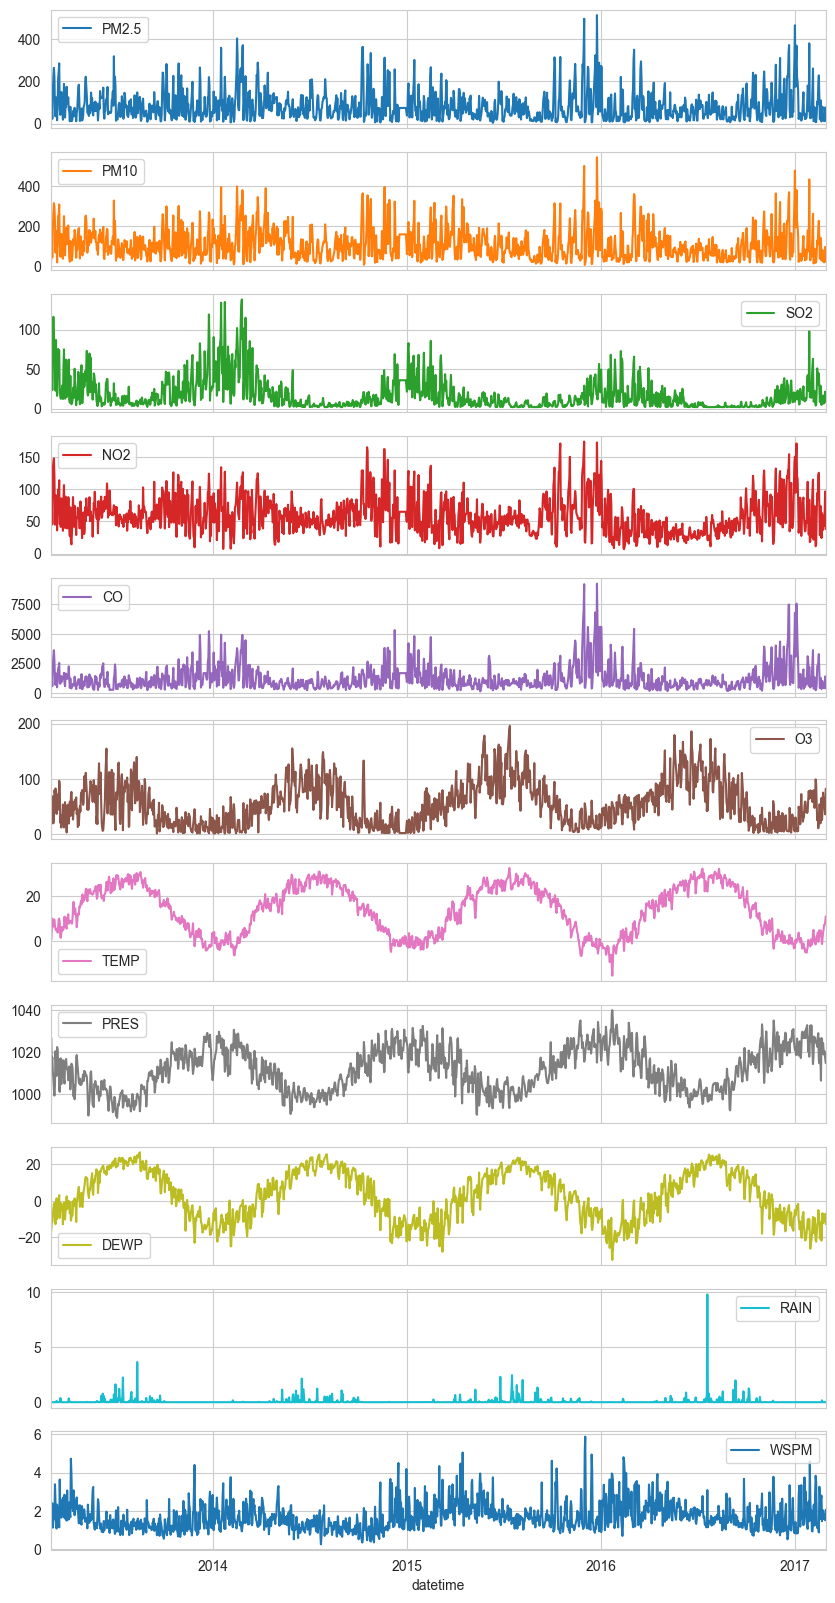

In [76]:
_ = df_daily.plot(subplots=True, figsize=(10, 20))

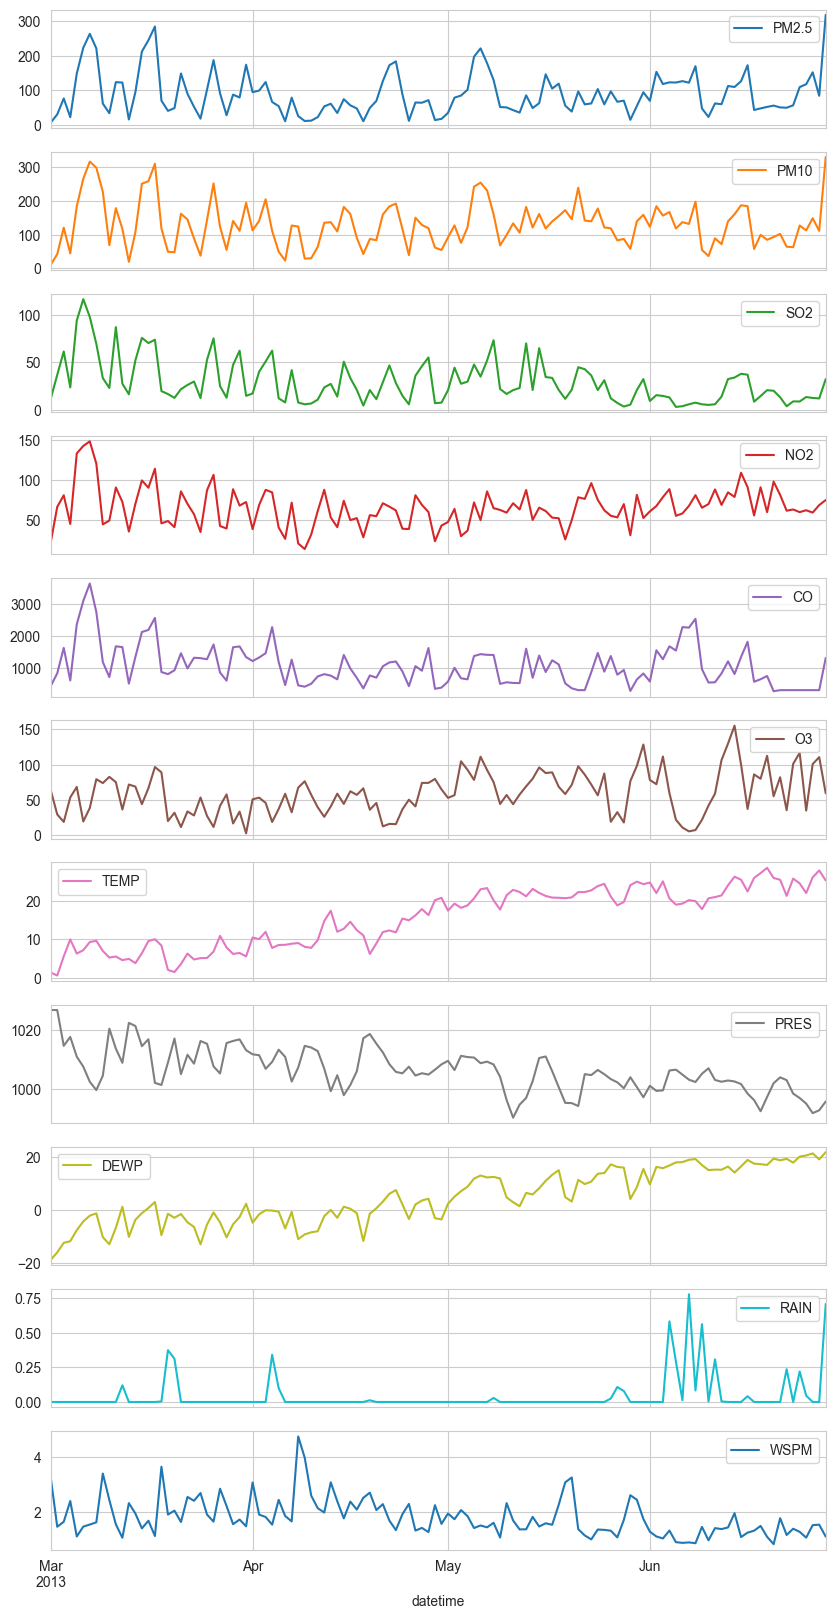

In [77]:
_ = df_daily[:120].plot(subplots=True, figsize=(10, 20))

# Feature Correlation

## Pearson Correlation

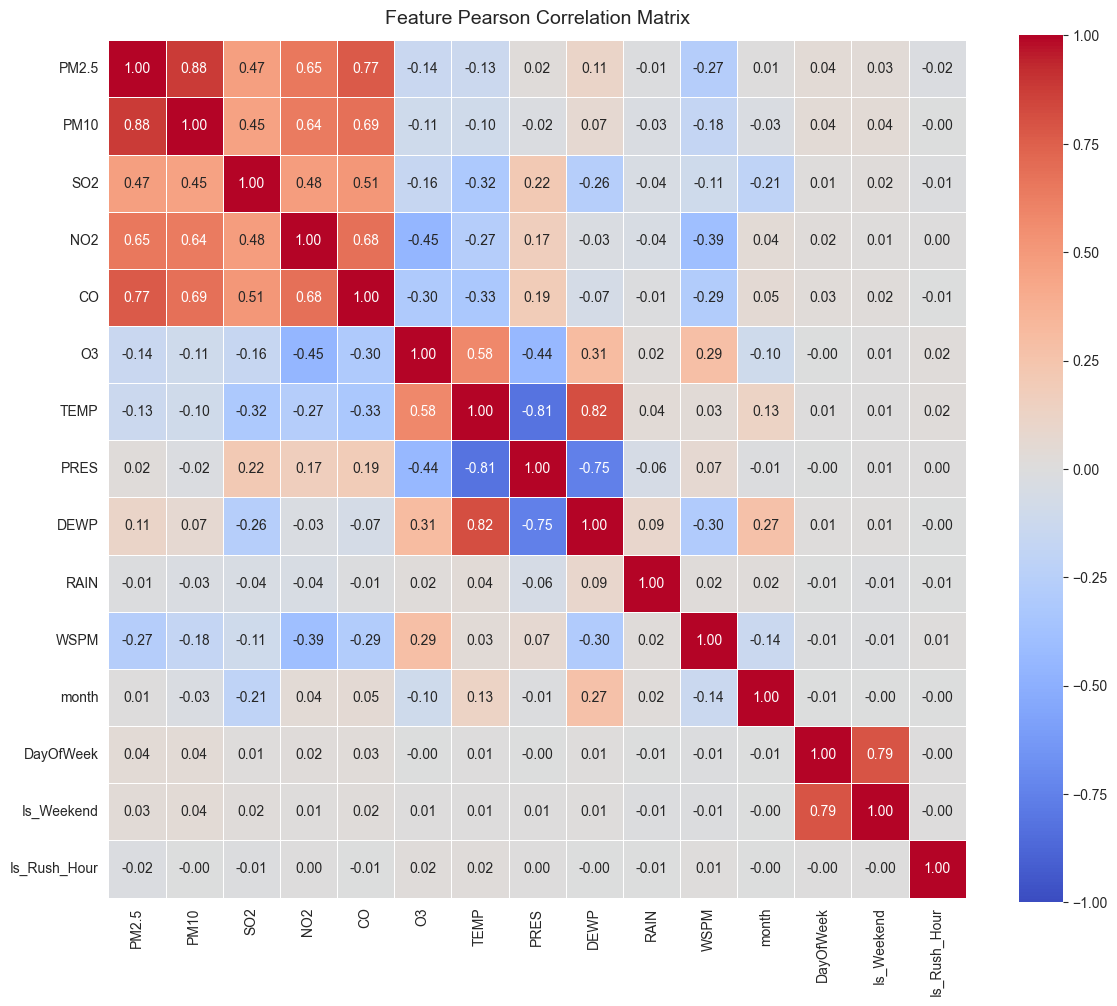

In [126]:
numeric_cols = [
    'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
    'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'month',
    'DayOfWeek', 'Is_Weekend', 'Is_Rush_Hour'
]

corr_matrix = df_all[numeric_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Feature Pearson Correlation Matrix', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

## Spearman Correlation

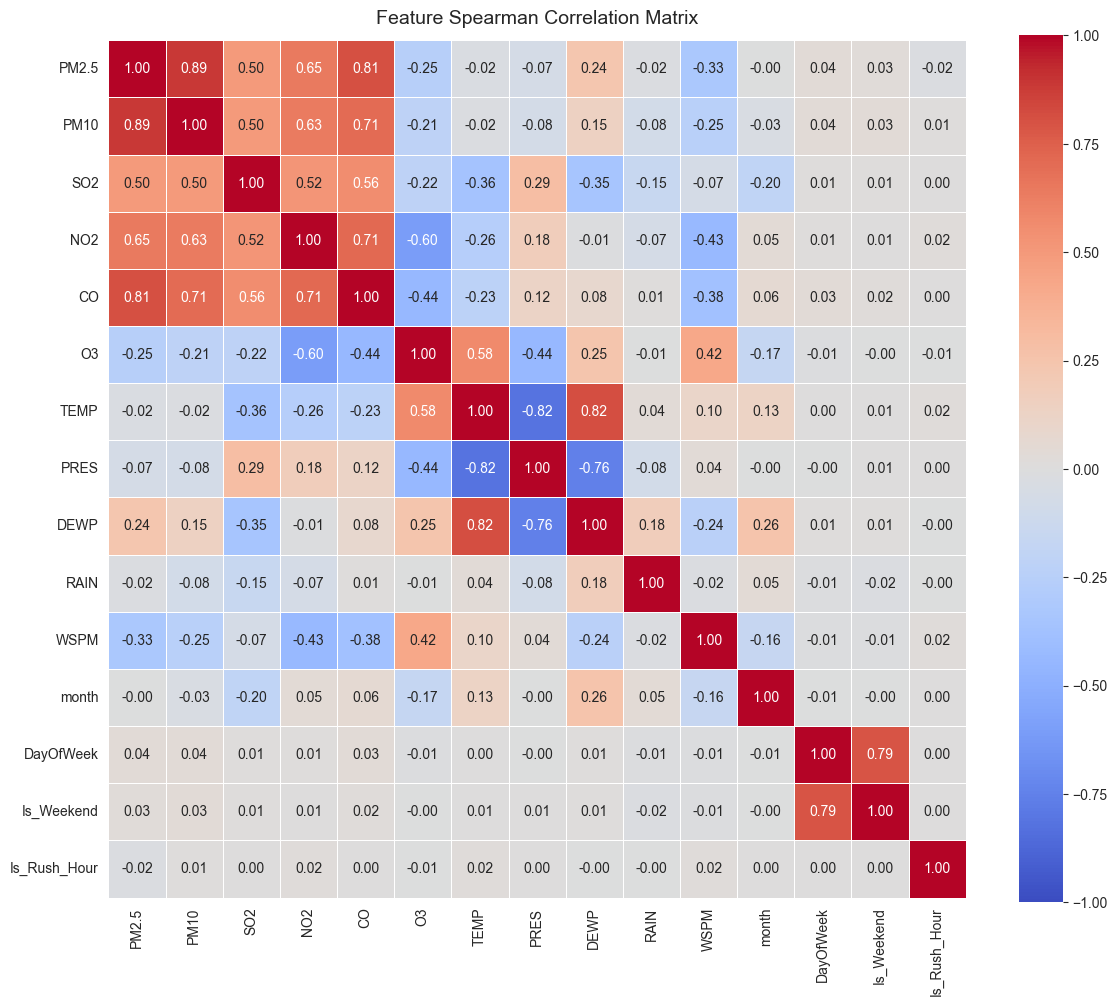

In [79]:
corr_matrix = df_all[numeric_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Feature Spearman Correlation Matrix', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

# Naive Forecast, Moving Average Forecast, Seasonal Naive Forecast

In [80]:
grouped = df_all.groupby('station')['PM2.5']

# 1. Naive Forecast (Shift by 1 hour, grouped by station)
df_all['Naive_Forecast'] = grouped.shift(1)

# 2. Moving Average Forecast (3-hour rolling average, grouped by station)
df_all['Moving_Avg_Forecast'] = grouped.transform(lambda x: x.rolling(window=3).mean().shift(1))

# 3. Seasonal Naive Forecast (Shift by 24 hours, grouped by station)
df_all['Seasonal_Naive_Forecast'] = grouped.shift(24)

In [81]:
df_all['Is_Hazardous'] = (df_all['PM2.5'] > 75).astype(int)
df_all['Naive_Is_Hazardous'] = (df_all['Naive_Forecast'] > 75).astype(int)
df_all['Moving_Avg_Is_Hazardous'] = (df_all['Moving_Avg_Forecast'] > 75).astype(int)
df_all['Seasonal_Naive_Is_Hazardous'] = (df_all['Seasonal_Naive_Forecast'] > 75).astype(int)

# Time Series Decomposition


In [82]:
df_all[df_all['station'] == 'Aotizhongxin']["datetime"]

0       2013-03-01 00:00:00
1       2013-03-01 01:00:00
2       2013-03-01 02:00:00
3       2013-03-01 03:00:00
4       2013-03-01 04:00:00
                ...        
35059   2017-02-28 19:00:00
35060   2017-02-28 20:00:00
35061   2017-02-28 21:00:00
35062   2017-02-28 22:00:00
35063   2017-02-28 23:00:00
Name: datetime, Length: 35064, dtype: datetime64[us]

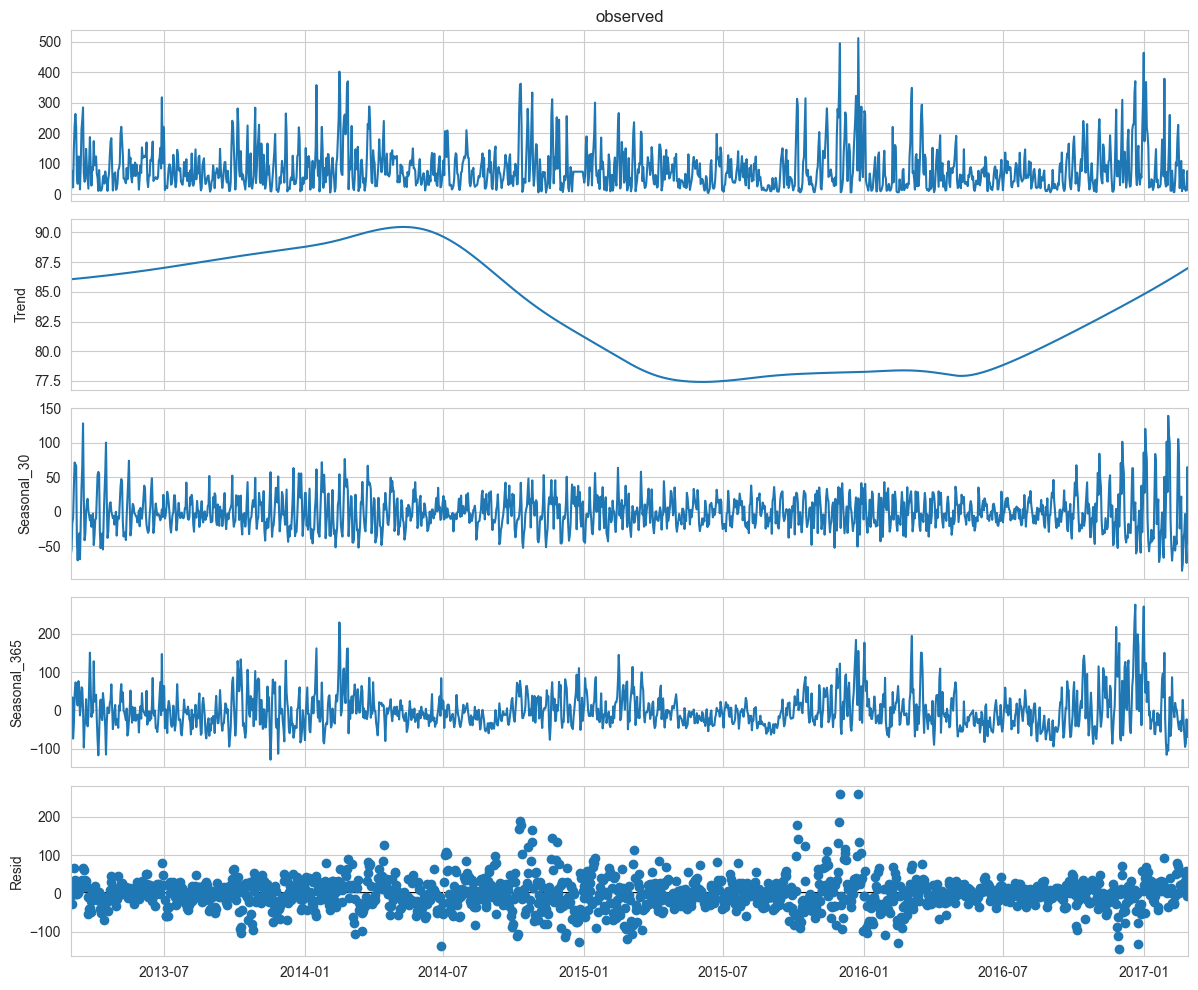

In [83]:
df_single_station = df_all[df_all['station'] == 'Aotizhongxin'].copy()
df_single_station.set_index("datetime", inplace=True)
df_daily = df_single_station['PM2.5'].resample('D').mean().dropna()

# Decompose with both monthly (30-day) and yearly (365-day) seasonal components
decomposition = MSTL(df_daily, periods=(30, 365)).fit()

fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.tight_layout()
plt.show()

# Extreme Values

# Time-based Cross-Validation

In [84]:
ts_cv = TimeSeriesSplit(
    n_splits=5,
    gap=48,
    max_train_size=10000,
    test_size=1000,
)

# Prep for Training

Rescale the target variable (PM2.5) to predict a relative demand so that the mean absolute error is more easily interpreted as a fraction of the maximum demand.

Note

The fit method of the models used in this notebook all minimizes the mean squared error to estimate the conditional mean. The absolute error, however, would estimate the conditional median.

Nevertheless, when reporting performance measures on the test set in the discussion, we choose to focus on the mean absolute error instead of the (root) mean squared error because it is more intuitive to interpret. Note, however, that in this study the best models for one metric are also the best ones in terms of the other metric.

https://scikit-learn.org/stable/auto_examples/applications/plot_cyclical_feature_engineering.html


In [85]:
# 1 & 2: Drop columns the model shouldn't see
columns_to_drop = ['datetime', 'PM2.5', 'Naive_Forecast', 'Moving_Avg_Forecast', 'Seasonal_Naive_Forecast',
                   'Is_Hazardous', 'Naive_Is_Hazardous', 'Moving_Avg_Is_Hazardous', 'Seasonal_Naive_Is_Hazardous']
df_model_ready = df_all.drop(columns=columns_to_drop)

# One-Hot Encoding for Wind Direction and Station + X & y

In [112]:
# 3: Convert text categories (Station Name and Wind Direction) into numbers
X = pd.get_dummies(df_model_ready, columns=['station', 'wd'], drop_first=True)
y = df_all['PM2.5'] # / df_all["PM2.5"].max()

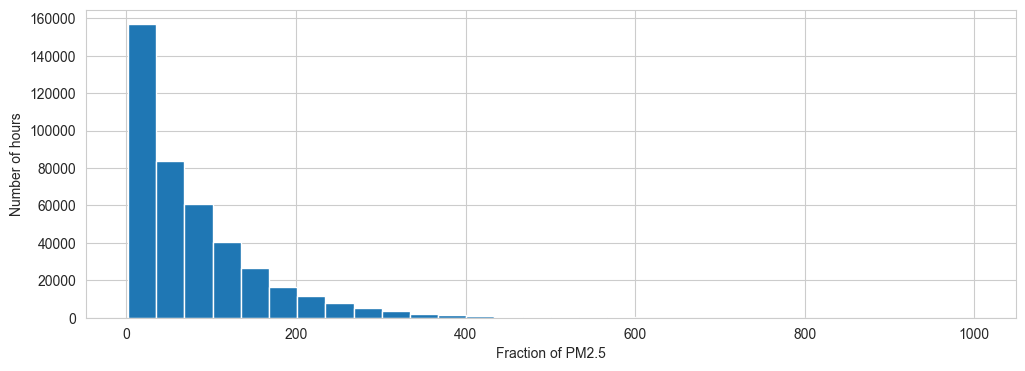

In [113]:
fig, ax = plt.subplots(figsize=(12, 4))
y.hist(bins=30, ax=ax)
_ = ax.set(
    xlabel="Fraction of PM2.5",
    ylabel="Number of hours",
)

# Dimensionality Reduction

In [114]:
# T-SNE Implementation
# X_reduced_tsne = TSNE(n_components=2, random_state=42).fit_transform(X.values)

In [115]:
# PCA Implementation
X_reduced_pca = PCA(n_components=2, random_state=69420).fit_transform(X.values)

In [116]:
# TruncatedSVD
X_reduced_svd = TruncatedSVD(n_components=2, algorithm='randomized', random_state=69420).fit_transform(X.values)

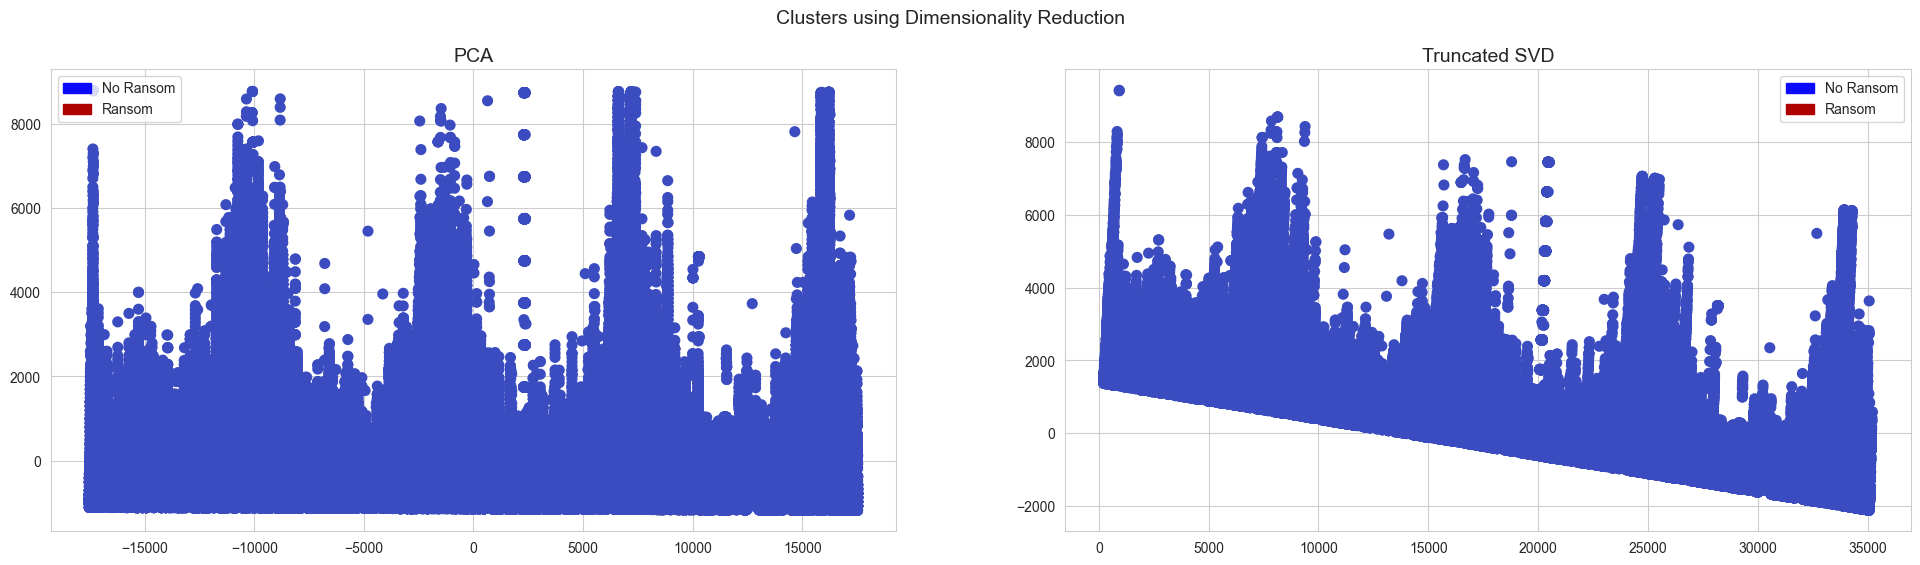

In [127]:
f, (ax2, ax3) = plt.subplots(1, 2, figsize=(24,6))
# labels = ['No Fraud', 'Fraud']
f.suptitle('Clusters using Dimensionality Reduction', fontsize=14)


blue_patch = mpl.patches.Patch(color='#0A0AFF', label='No Ransom')
red_patch = mpl.patches.Patch(color='#AF0000', label='Ransom')


# t-SNE scatter plot
# ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 0), cmap='coolwarm', label='No Ransom', linewidths=2)
# ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 1), cmap='coolwarm', label='Ransom', linewidths=2)
# ax1.set_title('t-SNE', fontsize=14)

# ax1.grid(True)

# ax1.legend(handles=[blue_patch, red_patch])


# PCA scatter plot
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 0), cmap='coolwarm', linewidths=2)
# ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=y, cmap='coolwarm', label='Ransom', linewidths=2)
ax2.set_title('PCA', fontsize=14)

ax2.grid(True)

ax2.legend(handles=[blue_patch, red_patch])

# TruncatedSVD scatter plot
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 0), cmap='coolwarm', linewidths=2)
# ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 1), cmap='coolwarm', label='Ransom', linewidths=2)
ax3.set_title('Truncated SVD', fontsize=14)

ax3.grid(True)

ax3.legend(handles=[blue_patch, red_patch])

plt.show()

# Time Lag Experiment

In [118]:
from scipy.stats import pearsonr
import warnings

# ── Config ────────────────────────────────────────────────────────────────────
TARGET    = 'PM2.5'                        # correlate against raw PM2.5
LAG_RANGE = range(1, 49)                   # test lags 1h → 48h
FEATURES  = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
             'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']


In [123]:
# ── 1. Compute Pearson r at each lag for each feature ─────────────────────────
# Work on a single station to keep temporal ordering clean
df_station = df_all.copy()

results = []

for feature in FEATURES:
    for lag in LAG_RANGE:
        lagged  = df_station[feature].shift(lag)       # feature at time t-lag
        target  = df_station[TARGET]                   # PM2.5 at time t

        # Drop NaNs introduced by shift
        valid   = pd.concat([lagged, target], axis=1).dropna()

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            r, p = pearsonr(valid.iloc[:, 0], valid.iloc[:, 1])

        results.append({
            'Feature': feature,
            'Lag (hours)': lag,
            'Pearson r': r,
            'p-value': p,
            'Significant': p < 0.05
        })

results_df = pd.DataFrame(results)


In [124]:
# ── 2. Find optimal lag per feature (highest |r|) ─────────────────────────────
best_lags = (
    results_df.loc[results_df.groupby('Feature')['Pearson r']
                              .apply(lambda x: x.abs().idxmax())]
    .sort_values('Pearson r', ascending=False)
    .reset_index(drop=True)
)
print("Optimal lag per feature:")
print(best_lags[['Feature', 'Lag (hours)', 'Pearson r', 'p-value']].to_string(index=False))


Optimal lag per feature:
Feature  Lag (hours)  Pearson r       p-value
  PM2.5            1   0.968272  0.000000e+00
   PM10            1   0.859205  0.000000e+00
     CO            1   0.757680  0.000000e+00
    NO2            1   0.654302  0.000000e+00
    SO2            1   0.464749  0.000000e+00
   PRES           48   0.196125  0.000000e+00
   DEWP            1   0.113121  0.000000e+00
   RAIN            4  -0.038320 1.756529e-136
     O3            1  -0.148035  0.000000e+00
   TEMP           44  -0.169966  0.000000e+00
   WSPM            3  -0.299092  0.000000e+00


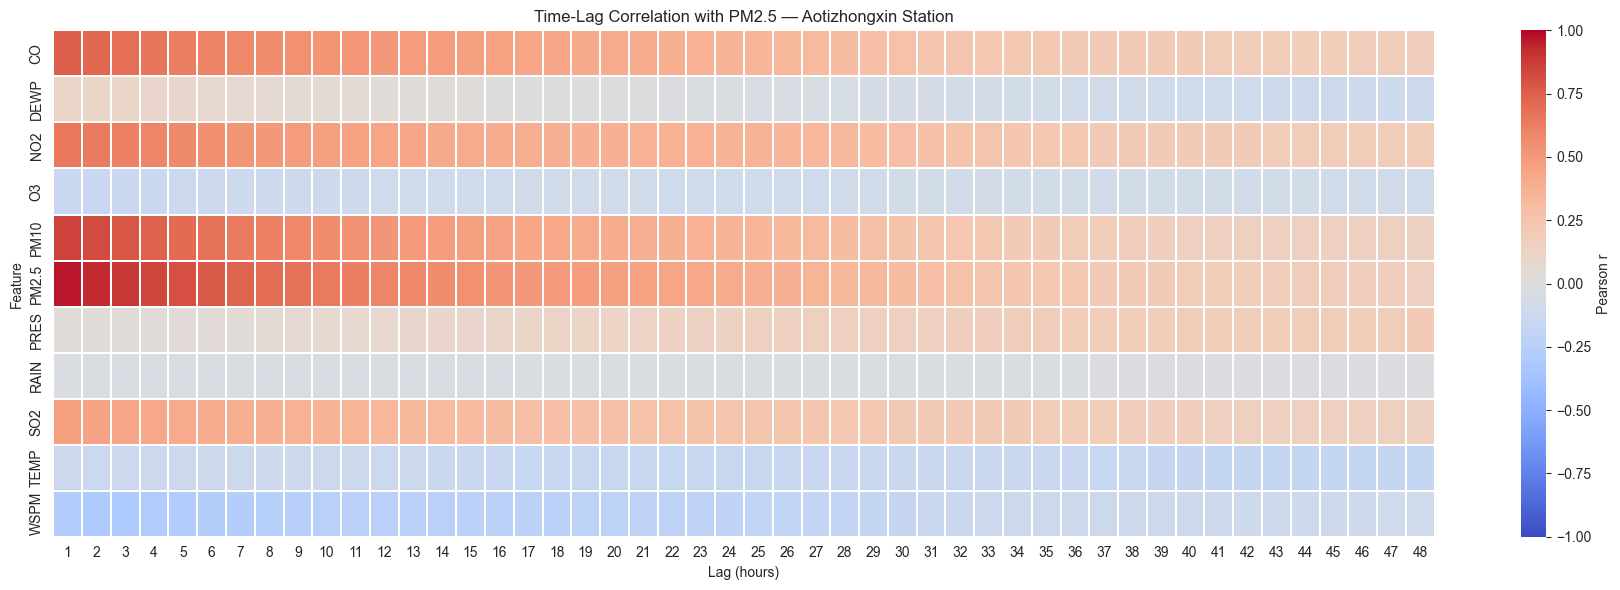

In [125]:
# ── 3. Heatmap — Pearson r across all features and lags ──────────────────────
pivot = results_df.pivot(index='Feature', columns='Lag (hours)', values='Pearson r')

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(
    pivot,
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.2, ax=ax,
    cbar_kws={'label': 'Pearson r'}
)
ax.set_title(f'Time-Lag Correlation with {TARGET} — Aotizhongxin Station')
ax.set_xlabel('Lag (hours)')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()


In [ ]:
# ── 4. Line plot — correlation decay curves per feature ──────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
for feature in FEATURES:
    subset = results_df[results_df['Feature'] == feature]
    ax.plot(subset['Lag (hours)'], subset['Pearson r'], label=feature, linewidth=1.5)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Lag (hours)')
ax.set_ylabel('Pearson r')
ax.set_title(f'Correlation Decay Curves — Feature vs {TARGET} at Increasing Lags')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# ── 5. (Optional) Add optimal lag features back to the model ─────────────────
for _, row in best_lags.iterrows():
    feat    = row['Feature']
    optimal = int(row['Lag (hours)'])
    col     = f"{feat}_lag{optimal}"
    df_all[col] = df_all.groupby('station')[feat].shift(optimal)
    print(f"Added: {col}  (r={row['Pearson r']:.3f})")

## Pearson Correlation

## Spearman Correlation

# Feature Engineering

In [88]:
categorical_columns = df_all.columns[df_all.dtypes == "category"]

In [89]:
print("Categorical features:", categorical_columns.tolist())

Categorical features: []


In [90]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import RidgeCV


alphas = np.logspace(-6, 6, 25)

cyclic_cossin_transformer = ColumnTransformer(
    transformers=[
        ("categorical", one_hot_encoder, categorical_columns),
        ("month_sin", sin_transformer(12), ["month"]),
        ("month_cos", cos_transformer(12), ["month"]),
        ("weekday_sin", sin_transformer(7), ["DayOfWeek"]),
        ("weekday_cos", cos_transformer(7), ["DayOfWeek"]),
        ("hour_sin", sin_transformer(24), ["hour"]),
        ("hour_cos", cos_transformer(24), ["hour"]),
    ],
    remainder=MinMaxScaler(),
)

cyclic_cossin_linear_pipeline = make_pipeline(
    cyclic_cossin_transformer,
    RidgeCV(alphas=alphas),
)
evaluate(cyclic_cossin_linear_pipeline, X, y, cv=ts_cv)

Mean Absolute Error:     0.278 +/- 0.033
Root Mean Squared Error: 0.339 +/- 0.020


## Scale/Normalize The Data

https://www.tensorflow.org/tutorials/structured_data/time_series#normalize_the_data

In [98]:
def plotViolin(df, train_mean, train_std):
    df_std = (df - train_mean) / train_std
    df_std = df_std.melt(var_name='Column', value_name='Normalized')
    plt.figure(figsize=(12, 6))
    ax = sns.violinplot(x='Column', y='Normalized', data=df_std)
    _ = ax.set_xticklabels(df.keys(), rotation=90)


In [99]:
def standardScale(x_train, x_test, y_train, y_test, df):
    train_mean = x_train.mean()
    train_std = x_train.std()

    X_train_scaled = (x_train - train_mean) / train_std
    # val_df = (val_df - train_mean) / train_std
    X_test_scaled = (x_test - train_mean) / train_std

    y_train_array = y_train.values
    y_test_array = y_test.values

    # plotViolin(df, train_mean, train_std)

    return X_train_scaled, X_test_scaled, y_train_array, y_test_array

In [100]:
def minMaxScale(X_train, X_test, y_train, y_test, df):
    train_mean = X_train.mean()
    train_std = X_train.std()

    X_train_scaled = (X_train - train_mean) / train_std
    # val_df = (val_df - train_mean) / train_std
    X_test_scaled = (X_test - train_mean) / train_std

    y_train_array = y_train.values
    y_test_array = y_test.values

    # plotViolin(df, train_mean, train_std)

    return X_train_scaled, X_test_scaled, y_train_array, y_test_array

# Decision Tree

In [58]:
dt_model = DecisionTreeClassifier(max_depth=5)

In [59]:
def plot_roc_curve(fpr, tpr, roc_auc, fold):
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'Decision Tree (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (Predicting Hazardous when it is Safe)')
    plt.ylabel('True Positive Rate (Correctly Predicting Hazardous)')
    plt.title(f'ROC Curve - Air Quality (Fold {fold})')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

Fold 1 F1 Score: 0.76


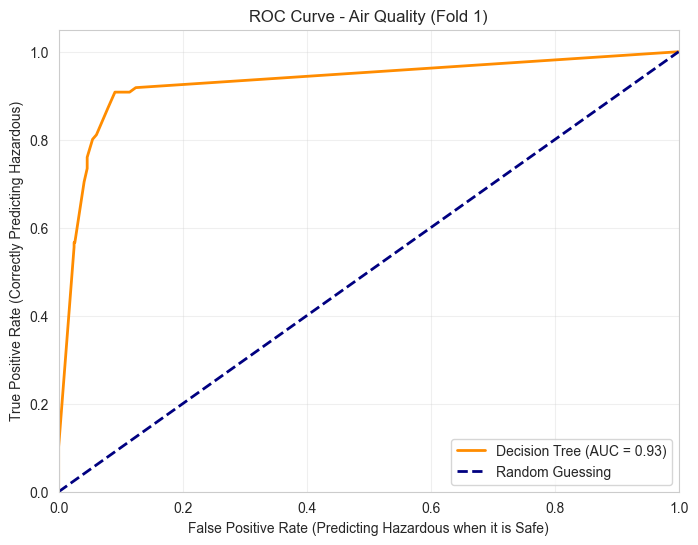

Fold 2 F1 Score: 0.87


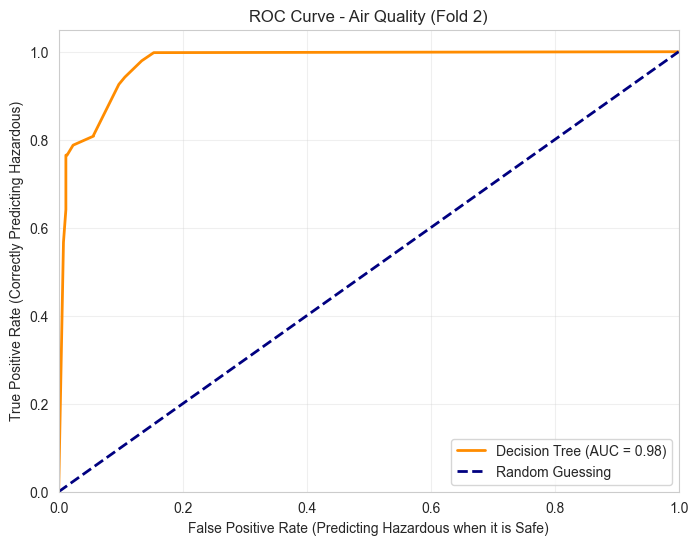

Fold 3 F1 Score: 0.92


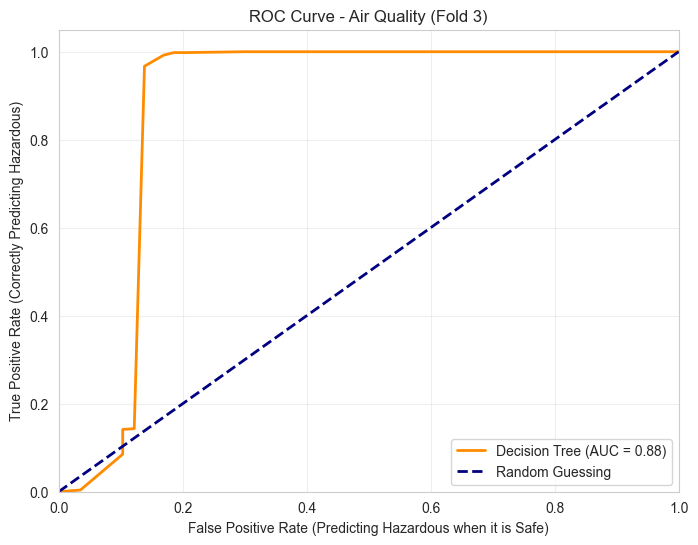

Fold 4 F1 Score: 0.96


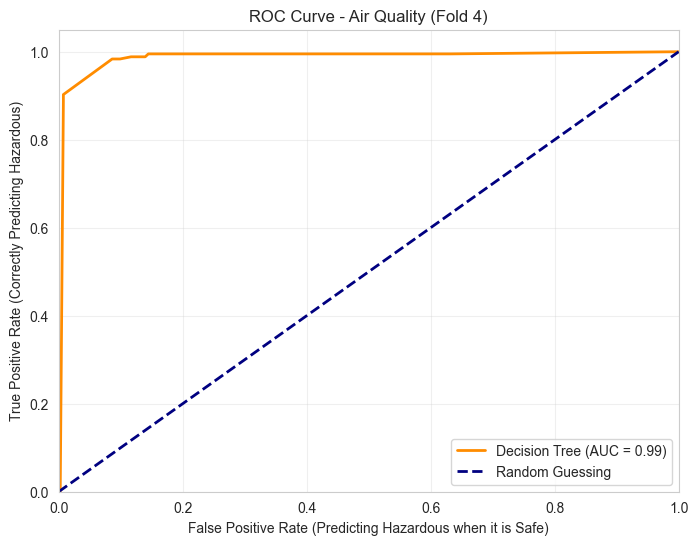

Fold 5 F1 Score: 0.93


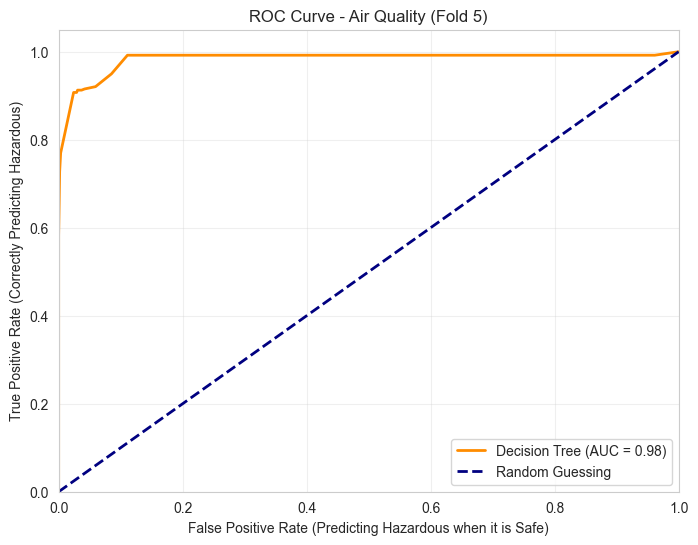

In [60]:
for fold, (train_index, test_index) in enumerate(ts_cv.split(X, y), start=1):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    dt_model.fit(X_train, y_train)
    predictions = dt_model.predict(X_test)

    f1 = f1_score(y_test, predictions)
    print(f"Fold {fold} F1 Score: {f1:.2f}")

    y_proba = dt_model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plot_roc_curve(fpr, tpr, roc_auc, fold)

Fold 1 F1 Score: 0.76


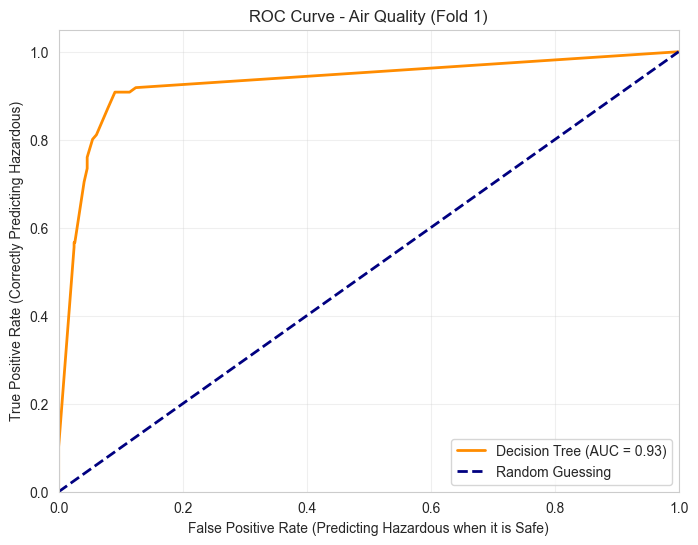

Fold 2 F1 Score: 0.87


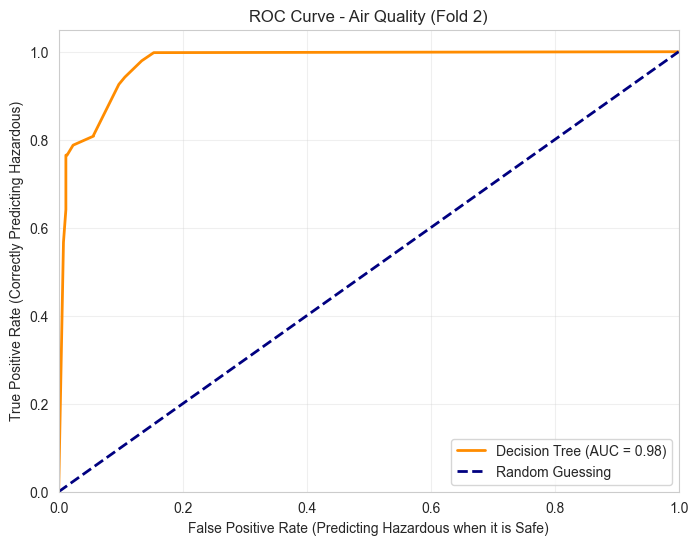

Fold 3 F1 Score: 0.92


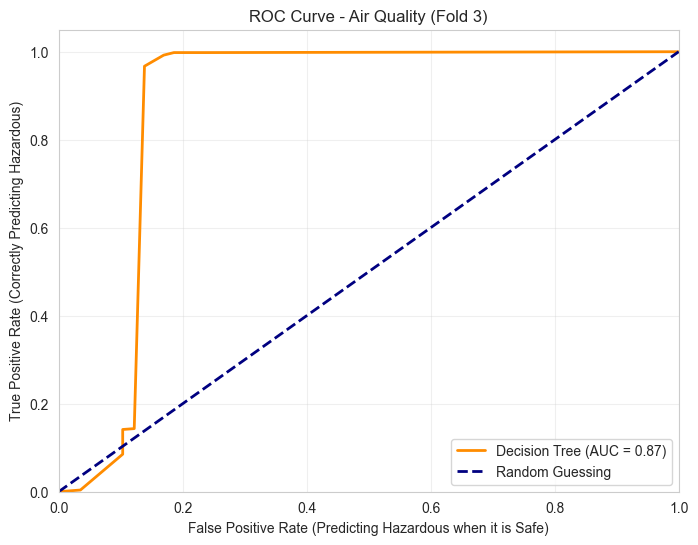

Fold 4 F1 Score: 0.96


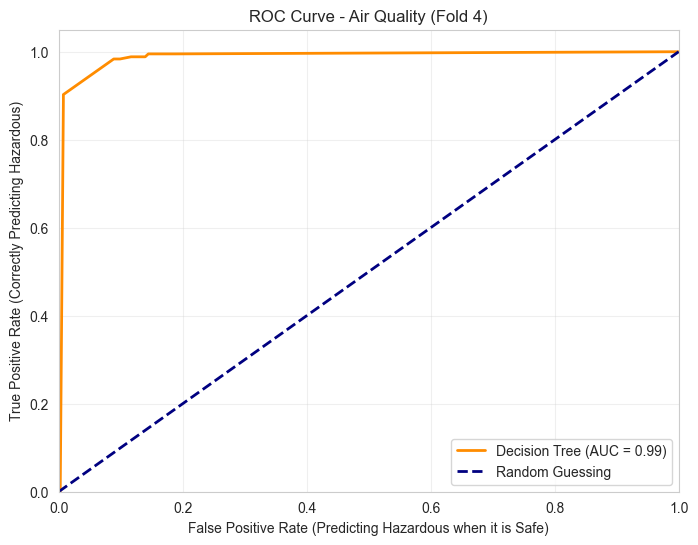

Fold 5 F1 Score: 0.93


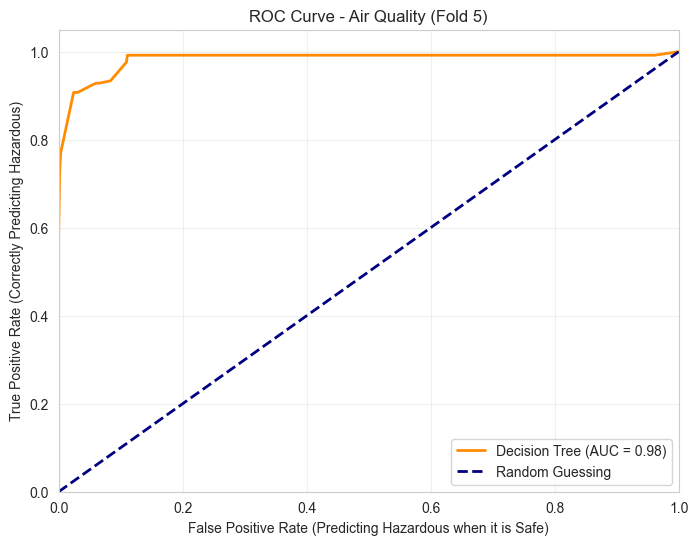

In [101]:
for fold, (train_index, test_index) in enumerate(ts_cv.split(X, y), start=1):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    X_train_scaled, X_test_scaled, _, _ = standardScale(X_train, X_test, y_train, y_test, X)

    dt_model.fit(X_train_scaled, y_train)
    predictions = dt_model.predict(X_test_scaled)

    f1 = f1_score(y_test, predictions)
    print(f"Fold {fold} F1 Score: {f1:.2f}")

    y_proba = dt_model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plot_roc_curve(fpr, tpr, roc_auc, fold)

Fold 1
                                 F1  Precision  Recall  Accuracy
Naive Forecast                0.929      0.929   0.929     0.944
3hr Moving Average Forecast   0.891      0.887   0.895     0.914
Decision Tree                 0.881      0.870   0.893     0.906
24 Hr Seasonal Naive Forecast 0.560      0.560   0.560     0.655


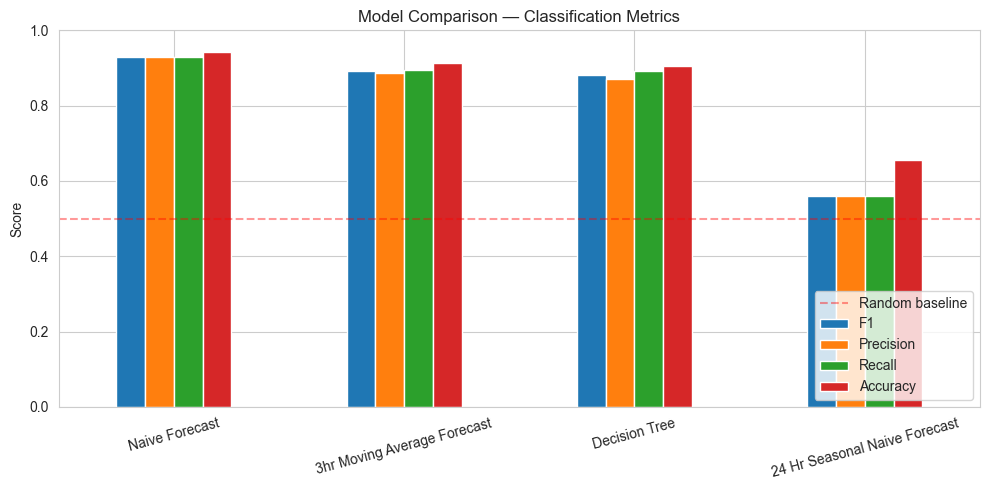

Fold 2
                                 F1  Precision  Recall  Accuracy
Naive Forecast                0.929      0.929   0.929     0.944
3hr Moving Average Forecast   0.891      0.887   0.895     0.914
Decision Tree                 0.881      0.870   0.893     0.906
24 Hr Seasonal Naive Forecast 0.560      0.560   0.560     0.655


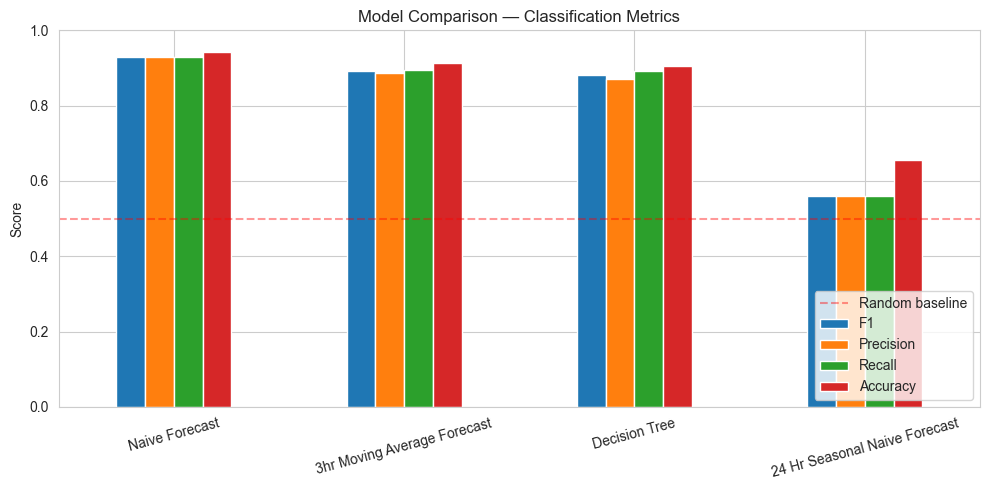

Fold 3
                                 F1  Precision  Recall  Accuracy
Naive Forecast                0.929      0.929   0.929     0.944
3hr Moving Average Forecast   0.891      0.887   0.895     0.914
Decision Tree                 0.881      0.870   0.893     0.906
24 Hr Seasonal Naive Forecast 0.560      0.560   0.560     0.655


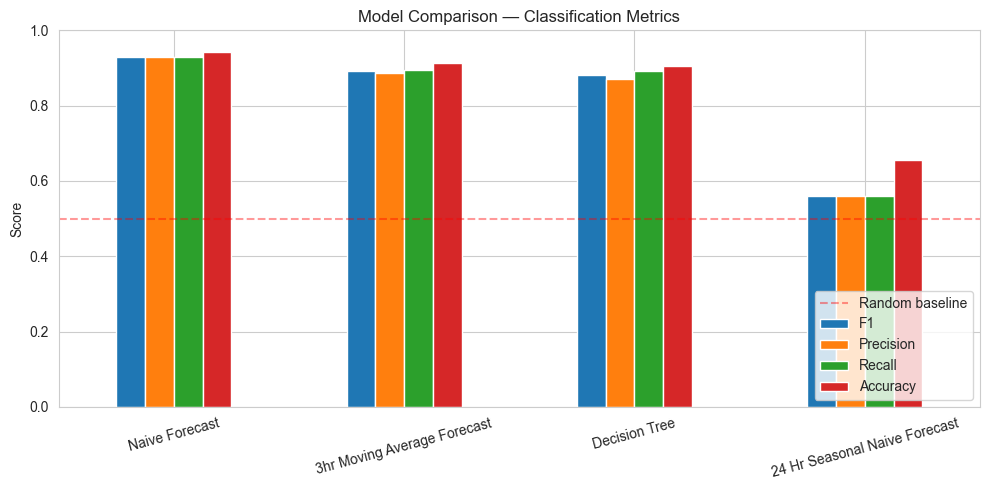

Fold 4
                                 F1  Precision  Recall  Accuracy
Naive Forecast                0.929      0.929   0.929     0.944
3hr Moving Average Forecast   0.891      0.887   0.895     0.914
Decision Tree                 0.881      0.870   0.893     0.906
24 Hr Seasonal Naive Forecast 0.560      0.560   0.560     0.655


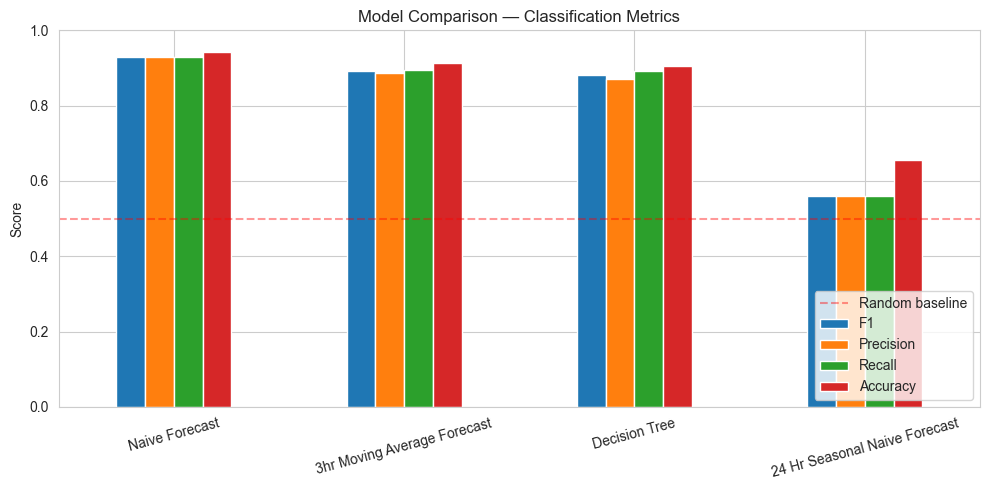

Fold 5
                                 F1  Precision  Recall  Accuracy
Naive Forecast                0.929      0.929   0.929     0.944
3hr Moving Average Forecast   0.891      0.887   0.895     0.914
Decision Tree                 0.881      0.870   0.893     0.906
24 Hr Seasonal Naive Forecast 0.560      0.560   0.560     0.655


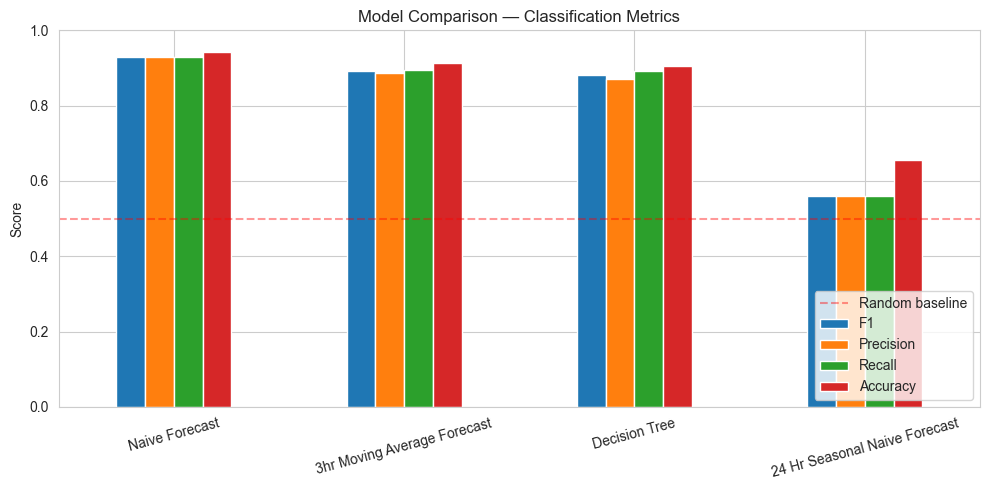

In [62]:
# --- Assumes your binary target was created with a threshold, e.g.:
# df_all['Is_Hazardous'] = (df_all['PM2.5'] > 75).astype(int)
THRESHOLD = 75

# 1. Drop rows where any forecast is NaN (Seasonal Naive needs 24 prior rows)
compare_df = df_all[['PM2.5', 'Is_Hazardous',
                      'Naive_Forecast',
                      'Moving_Avg_Forecast',
                      'Seasonal_Naive_Forecast']].dropna()

X_true = compare_df.drop(columns=['PM2.5','Is_Hazardous','Naive_Forecast',
                      'Moving_Avg_Forecast',
                      'Seasonal_Naive_Forecast'])

y_true = compare_df['Is_Hazardous']

# 2. Binarize the naive forecasts using the same threshold as your target
baselines = {
    'Naive Forecast':           (compare_df['Naive_Forecast']           > THRESHOLD).astype(int),
    '3hr Moving Average Forecast':  (compare_df['Moving_Avg_Forecast']      > THRESHOLD).astype(int),
    '24 Hr Seasonal Naive Forecast':  (compare_df['Seasonal_Naive_Forecast']  > THRESHOLD).astype(int),
}

# 3. Collect scores
for fold, (train_index, test_index) in enumerate(ts_cv.split(X_true, y_true), start=1):
    results = {}
    for name, y_pred in baselines.items():
        results[name] = {
            'F1':        f1_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred),
            'Recall':    recall_score(y_true, y_pred),
            'Accuracy':  accuracy_score(y_true, y_pred),
        }

    # 4. Add Decision Tree — use final fold predictions or refit on full data
    dt_model.fit(X, y)
    y_pred_dt = dt_model.predict(X)
    results['Decision Tree'] = {
        'F1':        f1_score(y, y_pred_dt),
        'Precision': precision_score(y, y_pred_dt),
        'Recall':    recall_score(y, y_pred_dt),
        'Accuracy':  accuracy_score(y, y_pred_dt),
    }

    # 5. Display as a formatted table
    print(f"Fold {fold}")
    results_df = pd.DataFrame(results).T.sort_values('F1', ascending=False)
    print(results_df.to_string(float_format='{:.3f}'.format))

    # 6. Bar chart comparison
    results_df.plot(kind='bar', figsize=(10, 5), ylim=(0, 1), rot=15)
    plt.title('Model Comparison — Classification Metrics')
    plt.ylabel('Score')
    plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.4, label='Random baseline')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

Fold 1
                                 F1  Precision  Recall  Accuracy
Naive Forecast                0.929      0.929   0.929     0.944
3hr Moving Average Forecast   0.891      0.887   0.895     0.914
Decision Tree                 0.881      0.870   0.893     0.906
24 Hr Seasonal Naive Forecast 0.560      0.560   0.560     0.655


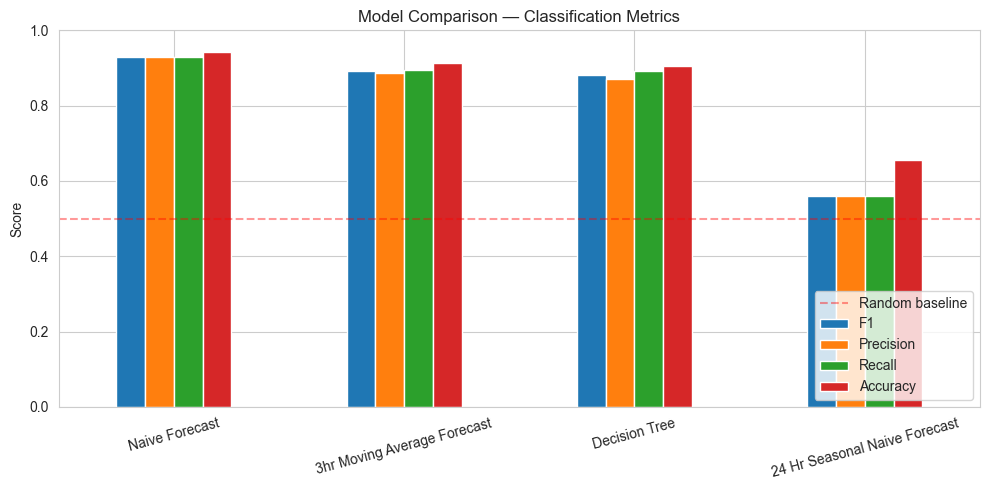

Fold 2
                                 F1  Precision  Recall  Accuracy
Naive Forecast                0.929      0.929   0.929     0.944
3hr Moving Average Forecast   0.891      0.887   0.895     0.914
Decision Tree                 0.881      0.870   0.893     0.906
24 Hr Seasonal Naive Forecast 0.560      0.560   0.560     0.655


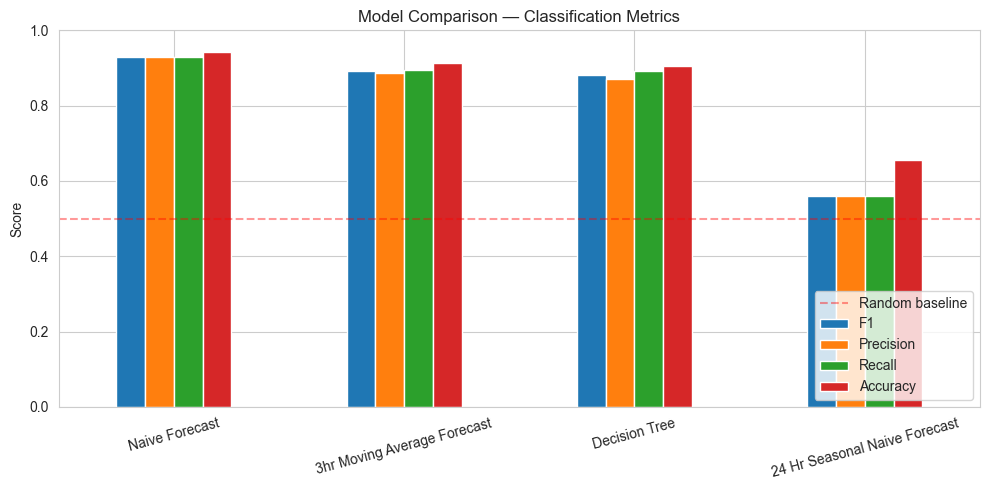

Fold 3
                                 F1  Precision  Recall  Accuracy
Naive Forecast                0.929      0.929   0.929     0.944
3hr Moving Average Forecast   0.891      0.887   0.895     0.914
Decision Tree                 0.881      0.870   0.893     0.906
24 Hr Seasonal Naive Forecast 0.560      0.560   0.560     0.655


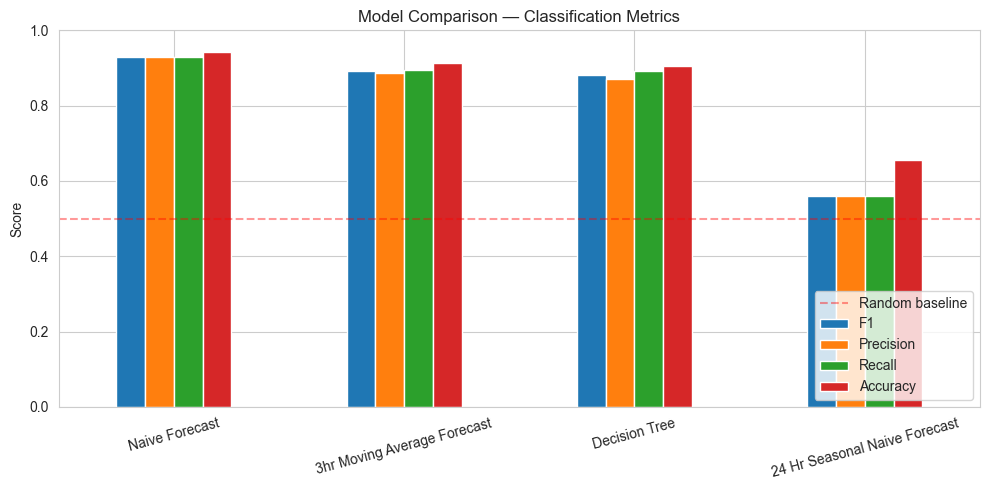

Fold 4
                                 F1  Precision  Recall  Accuracy
Naive Forecast                0.929      0.929   0.929     0.944
3hr Moving Average Forecast   0.891      0.887   0.895     0.914
Decision Tree                 0.881      0.870   0.893     0.906
24 Hr Seasonal Naive Forecast 0.560      0.560   0.560     0.655


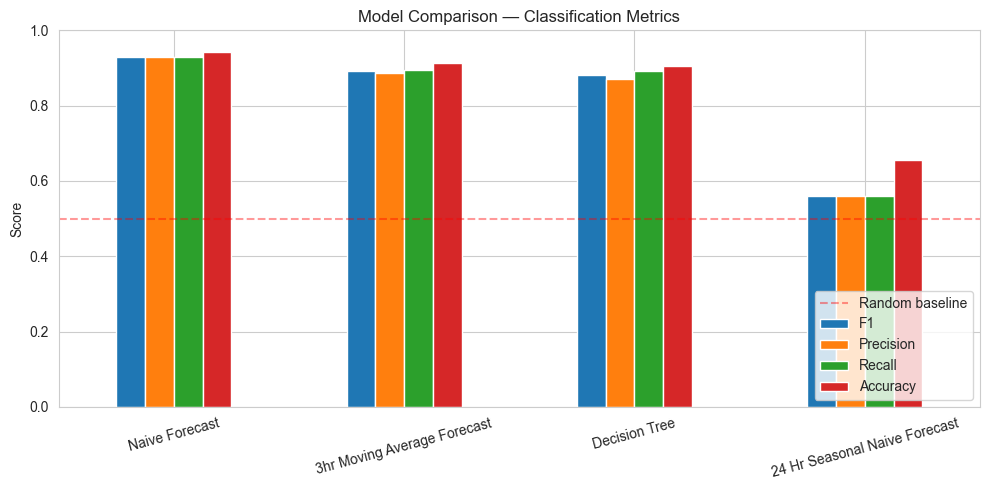

Fold 5
                                 F1  Precision  Recall  Accuracy
Naive Forecast                0.929      0.929   0.929     0.944
3hr Moving Average Forecast   0.891      0.887   0.895     0.914
Decision Tree                 0.881      0.870   0.893     0.906
24 Hr Seasonal Naive Forecast 0.560      0.560   0.560     0.655


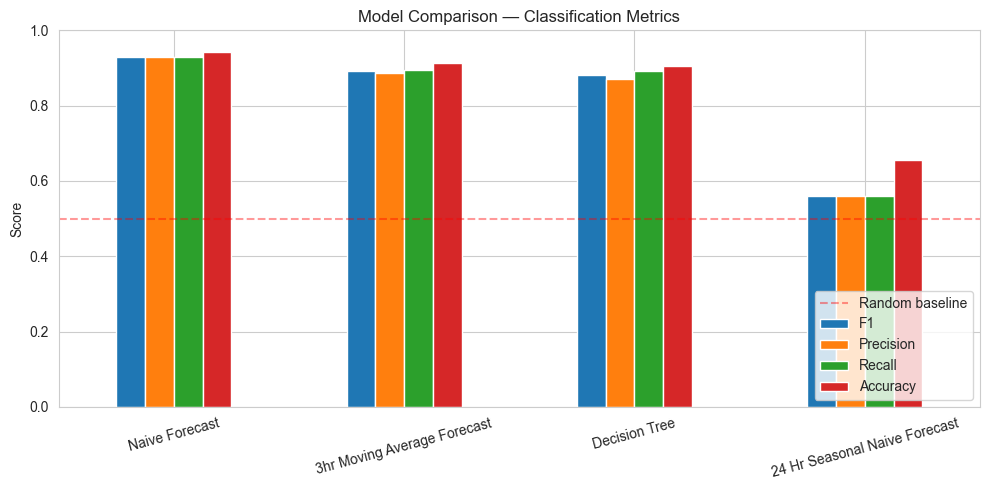

In [63]:
# --- Assumes your binary target was created with a threshold, e.g.:
# df_all['Is_Hazardous'] = (df_all['PM2.5'] > 75).astype(int)
THRESHOLD = 75

# 1. Drop rows where any forecast is NaN (Seasonal Naive needs 24 prior rows)
compare_df = df_all[['PM2.5', 'Is_Hazardous',
                      'Naive_Forecast',
                      'Moving_Avg_Forecast',
                      'Seasonal_Naive_Forecast']].dropna()

X_true = compare_df

y_true = compare_df['Is_Hazardous']

# 2. Binarize the naive forecasts using the same threshold as your target
baselines = {
    'Naive Forecast':           (compare_df['Naive_Forecast']           > THRESHOLD).astype(int),
    '3hr Moving Average Forecast':  (compare_df['Moving_Avg_Forecast']      > THRESHOLD).astype(int),
    '24 Hr Seasonal Naive Forecast':  (compare_df['Seasonal_Naive_Forecast']  > THRESHOLD).astype(int),
}

# 3. Collect scores
for fold, (train_index, test_index) in enumerate(ts_cv.split(X_true, y_true), start=1):
    results = {}
    for name, y_pred in baselines.items():
        results[name] = {
            'F1':        f1_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred),
            'Recall':    recall_score(y_true, y_pred),
            'Accuracy':  accuracy_score(y_true, y_pred),
        }

    # 4. Add Decision Tree — use final fold predictions or refit on full data
    dt_model.fit(X, y)
    y_pred_dt = dt_model.predict(X)
    results['Decision Tree'] = {
        'F1':        f1_score(y, y_pred_dt),
        'Precision': precision_score(y, y_pred_dt),
        'Recall':    recall_score(y, y_pred_dt),
        'Accuracy':  accuracy_score(y, y_pred_dt),
    }

    # 5. Display as a formatted table
    print(f"Fold {fold}")
    results_df = pd.DataFrame(results).T.sort_values('F1', ascending=False)
    print(results_df.to_string(float_format='{:.3f}'.format))

    # 6. Bar chart comparison
    results_df.plot(kind='bar', figsize=(10, 5), ylim=(0, 1), rot=15)
    plt.title('Model Comparison — Classification Metrics')
    plt.ylabel('Score')
    plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.4, label='Random baseline')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

## Predict 24 hours ahead

Fold 1 — DT F1: 0.403 | Naive F1: 0.262
Fold 2 — DT F1: 0.547 | Naive F1: 0.528
Fold 3 — DT F1: 0.682 | Naive F1: 0.507
Fold 4 — DT F1: 0.644 | Naive F1: 0.605
Fold 5 — DT F1: 0.423 | Naive F1: 0.381

Average across folds:
                        F1  Precision  Recall  Accuracy
Decision Tree (24h)  0.540      0.543   0.575     0.618
Seasonal Naive (24h) 0.457      0.454   0.460     0.559


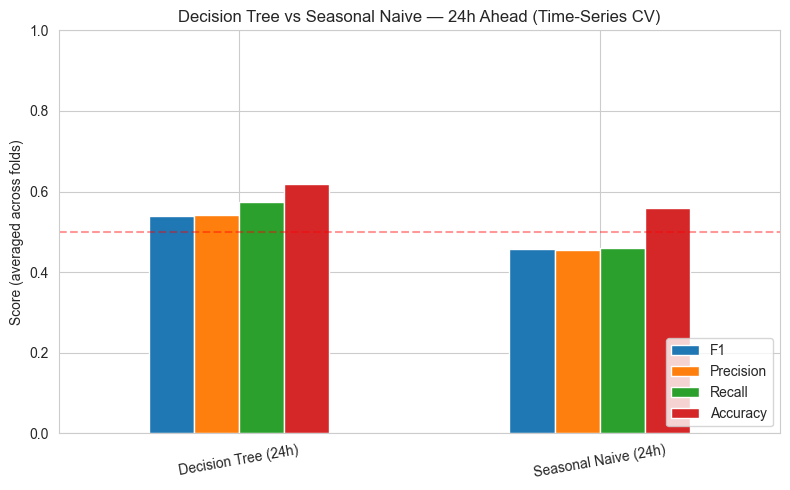

In [64]:
THRESHOLD = 75

# 1. Create the 24-hour-ahead target
df_all['PM2.5_24h_ahead'] = df_all.groupby('station')['PM2.5'].shift(-24)

# 2. Binarize it (hazardous 24 hours from now?)
df_all['Hazardous_24h'] = (df_all['PM2.5_24h_ahead'] > THRESHOLD).astype(int)

# 3. Build features — current conditions at time t
feature_cols = [
    'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
    'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM',
    'DayOfWeek', 'Is_Weekend', 'Is_Rush_Hour'
]

compare_df = df_all[feature_cols + ['Hazardous_24h', 'Seasonal_Naive_Forecast']].dropna()
X_aligned  = X.loc[compare_df.index]
y_true_all = compare_df['Hazardous_24h']
naive_all  = (compare_df['Seasonal_Naive_Forecast'] > THRESHOLD).astype(int)

dt_metrics    = {'F1': [], 'Precision': [], 'Recall': [], 'Accuracy': []}
naive_metrics = {'F1': [], 'Precision': [], 'Recall': [], 'Accuracy': []}

for fold, (train_index, test_index) in enumerate(ts_cv.split(X_aligned, y_true_all), start=1):
    X_train, X_test       = X_aligned.iloc[train_index], X_aligned.iloc[test_index]
    y_train, y_test       = y_true_all.iloc[train_index], y_true_all.iloc[test_index]
    naive_test            = naive_all.iloc[test_index]

    # Decision Tree
    dt_model.fit(X_train, y_train)
    y_pred = dt_model.predict(X_test)

    dt_metrics['F1'].append(f1_score(y_test, y_pred))
    dt_metrics['Precision'].append(precision_score(y_test, y_pred))
    dt_metrics['Recall'].append(recall_score(y_test, y_pred))
    dt_metrics['Accuracy'].append(accuracy_score(y_test, y_pred))

    # Seasonal Naive — same test window, no training needed
    naive_metrics['F1'].append(f1_score(y_test, naive_test))
    naive_metrics['Precision'].append(precision_score(y_test, naive_test))
    naive_metrics['Recall'].append(recall_score(y_test, naive_test))
    naive_metrics['Accuracy'].append(accuracy_score(y_test, naive_test))

    print(f"Fold {fold} — DT F1: {dt_metrics['F1'][-1]:.3f} | Naive F1: {naive_metrics['F1'][-1]:.3f}")

# Average across folds
results = {
    'Decision Tree (24h)':    {m: np.mean(v) for m, v in dt_metrics.items()},
    'Seasonal Naive (24h)':   {m: np.mean(v) for m, v in naive_metrics.items()},
}

results_df = pd.DataFrame(results).T.sort_values('F1', ascending=False)
print("\nAverage across folds:")
print(results_df.to_string(float_format='{:.3f}'.format))

results_df.plot(kind='bar', figsize=(8, 5), ylim=(0, 1), rot=10)
plt.title('Decision Tree vs Seasonal Naive — 24h Ahead (Time-Series CV)')
plt.ylabel('Score (averaged across folds)')
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.4)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Fold 1 | Decision Tree F1: 0.403 | Random Forest F1: 0.267 | XGBoost F1: 0.370 | Naive F1: 0.262
Fold 2 | Decision Tree F1: 0.547 | Random Forest F1: 0.336 | XGBoost F1: 0.482 | Naive F1: 0.528
Fold 3 | Decision Tree F1: 0.682 | Random Forest F1: 0.688 | XGBoost F1: 0.673 | Naive F1: 0.507
Fold 4 | Decision Tree F1: 0.638 | Random Forest F1: 0.647 | XGBoost F1: 0.643 | Naive F1: 0.605
Fold 5 | Decision Tree F1: 0.423 | Random Forest F1: 0.519 | XGBoost F1: 0.518 | Naive F1: 0.381

Average across folds:
                  F1  Precision  Recall  Accuracy
Decision Tree  0.539      0.542   0.573     0.617
XGBoost        0.537      0.566   0.554     0.624
Random Forest  0.491      0.574   0.462     0.645
Seasonal Naive 0.457      0.454   0.460     0.559


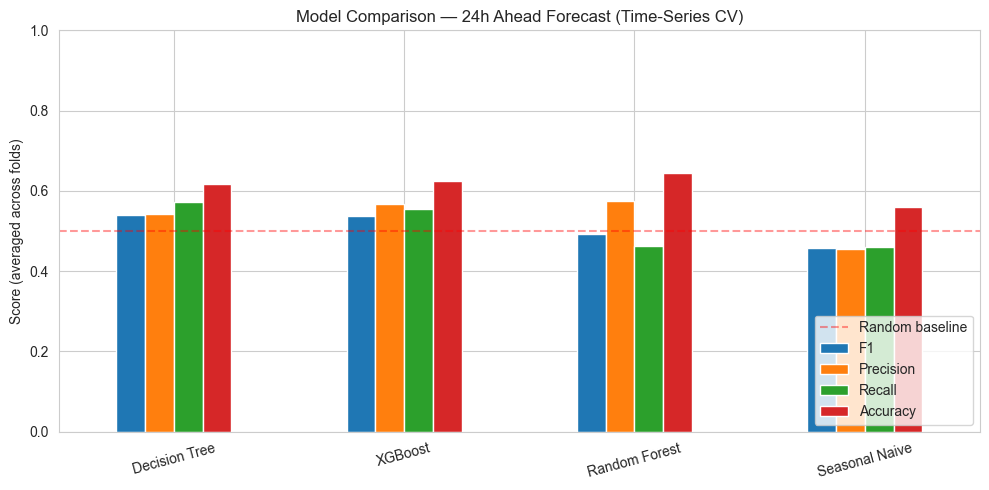

In [65]:
THRESHOLD = 75

compare_df = df_all[['Hazardous_24h', 'Seasonal_Naive_Forecast']].dropna()
X_aligned  = X.loc[compare_df.index]
y_true_all = compare_df['Hazardous_24h']
naive_all  = (compare_df['Seasonal_Naive_Forecast'] > THRESHOLD).astype(int)

# Define all models
models = {
    'Decision Tree':  dt_model,
    'Random Forest':  RandomForestClassifier(n_estimators=250, random_state=42, n_jobs=-1),
    'XGBoost':        XGBClassifier(n_estimators=100, random_state=42,
                                    eval_metric='logloss', verbosity=0),
}

# Initialise metric collectors for each model + naive
metric_keys = ['F1', 'Precision', 'Recall', 'Accuracy']
all_metrics  = {name: {m: [] for m in metric_keys} for name in models}
all_metrics['Seasonal Naive'] = {m: [] for m in metric_keys}

for fold, (train_index, test_index) in enumerate(ts_cv.split(X_aligned, y_true_all), start=1):
    X_train, X_test = X_aligned.iloc[train_index], X_aligned.iloc[test_index]
    y_train, y_test = y_true_all.iloc[train_index], y_true_all.iloc[test_index]
    naive_test      = naive_all.iloc[test_index]

    fold_summary = f"Fold {fold}"

    # ML models
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        all_metrics[name]['F1'].append(f1_score(y_test, y_pred))
        all_metrics[name]['Precision'].append(precision_score(y_test, y_pred))
        all_metrics[name]['Recall'].append(recall_score(y_test, y_pred))
        all_metrics[name]['Accuracy'].append(accuracy_score(y_test, y_pred))

        fold_summary += f" | {name} F1: {all_metrics[name]['F1'][-1]:.3f}"

    # Seasonal Naive — no training needed
    all_metrics['Seasonal Naive']['F1'].append(f1_score(y_test, naive_test))
    all_metrics['Seasonal Naive']['Precision'].append(precision_score(y_test, naive_test))
    all_metrics['Seasonal Naive']['Recall'].append(recall_score(y_test, naive_test))
    all_metrics['Seasonal Naive']['Accuracy'].append(accuracy_score(y_test, naive_test))

    fold_summary += f" | Naive F1: {all_metrics['Seasonal Naive']['F1'][-1]:.3f}"
    print(fold_summary)

# Average across folds
results_df = pd.DataFrame({
    name: {m: np.mean(v) for m, v in metrics.items()}
    for name, metrics in all_metrics.items()
}).T.sort_values('F1', ascending=False)

print("\nAverage across folds:")
print(results_df.to_string(float_format='{:.3f}'.format))

# Bar chart
results_df.plot(kind='bar', figsize=(10, 5), ylim=(0, 1), rot=15)
plt.title('Model Comparison — 24h Ahead Forecast (Time-Series CV)')
plt.ylabel('Score (averaged across folds)')
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.4, label='Random baseline')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## SHAP & Feature Importances

fig, axes = plt.subplots(len(models), 2, figsize=(16, 5 * len(models)))

for row, (name, model) in enumerate(models.items()):
    model.fit(X_aligned, y_true_all)

    # ── 1. Built-in Feature Importance (left column) ─────────────────────────
    importances = pd.Series(model.feature_importances_, index=X_aligned.columns)
    importances.sort_values().plot(
        kind='barh', ax=axes[row, 0], color='steelblue'
    )
    axes[row, 0].set_title(f'{name} — Feature Importance (Gini/Gain)')
    axes[row, 0].set_xlabel('Importance')

    # ── 2. SHAP (right column) ───────────────────────────────────────────────
    # TreeExplainer works for DT, RF, and XGBoost
    explainer  = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_aligned)

    # RF returns shap_values per class — take class 1 (Hazardous)
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values

    shap.summary_plot(
        sv, X_aligned,
        plot_type='bar',
        show=False,
        # ax=axes[row, 1]
    )
    axes[row, 1].set_title(f'{name} — SHAP Feature Importance')

plt.suptitle('Feature Importance vs SHAP — 24h Ahead Hazardous Air Quality',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── SHAP Beeswarm for your best model (shows direction of effect) ────────────
best_model_name = results_df.index[0]
best_model      = models[best_model_name]

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_aligned)
sv          = shap_values[1] if isinstance(shap_values, list) else shap_values

plt.figure()
shap.summary_plot(sv, X_aligned, show=False)
plt.title(f'SHAP Beeswarm — {best_model_name} (Best Model)')
plt.tight_layout()
plt.show()

# Deep Learning

# RNN, LSTM, CNN

In [102]:
WINDOW     = 24   # use the past 24 hours as context
THRESHOLD  = 75
BATCH_SIZE = 256
EPOCHS     = 30

# ── 2. Scale features (required for neural nets) ─────────────────────────────
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X_aligned)


In [103]:
# ── 3. Build sliding windows ──────────────────────────────────────────────────
# Each sample becomes a (WINDOW, n_features) sequence
def make_sequences(X, y, window):
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i - window:i])   # shape: (window, n_features)
        ys.append(y.iloc[i])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = make_sequences(X_scaled, y_true_all, WINDOW)
# X_seq shape: (n_samples, 24, n_features)

n_steps    = X_seq.shape[1]
n_features = X_seq.shape[2]


In [104]:
# ── 4. Model definitions ──────────────────────────────────────────────────────
def build_rnn():
    m = Sequential([
        SimpleRNN(64, input_shape=(n_steps, n_features), return_sequences=False),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

def build_lstm():
    m = Sequential([
        LSTM(64, input_shape=(n_steps, n_features), return_sequences=False),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

def build_cnn():
    m = Sequential([
        Conv1D(filters=64, kernel_size=3, activation='relu',
               input_shape=(n_steps, n_features)),
        Conv1D(filters=32, kernel_size=3, activation='relu'),
        GlobalMaxPooling1D(),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

builders = {
    'RNN':  build_rnn,
    'LSTM': build_lstm,
    'CNN':  build_cnn,
}

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


In [105]:
# ── 5. Time-series CV ─────────────────────────────────────────────────────────
nn_metrics = {name: {m: [] for m in metric_keys} for name in builders}

for fold, (train_idx, test_idx) in enumerate(ts_cv.split(X_seq, y_seq), start=1):
    X_train, X_test = X_seq[train_idx], X_seq[test_idx]
    y_train, y_test = y_seq[train_idx], y_seq[test_idx]

    fold_summary = f"Fold {fold}"

    for name, build_fn in builders.items():
        model = build_fn()   # fresh model each fold
        model.fit(
            X_train, y_train,
            validation_split=0.1,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=[early_stop],
            verbose=0
        )

        y_prob = model.predict(X_test, verbose=0).flatten()
        y_pred = (y_prob > 0.5).astype(int)

        nn_metrics[name]['F1'].append(f1_score(y_test, y_pred))
        nn_metrics[name]['Precision'].append(precision_score(y_test, y_pred))
        nn_metrics[name]['Recall'].append(recall_score(y_test, y_pred))
        nn_metrics[name]['Accuracy'].append(accuracy_score(y_test, y_pred))

        fold_summary += f" | {name} F1: {nn_metrics[name]['F1'][-1]:.3f}"

    print(fold_summary)


/Users/darronporter/Downloads/COMP4030 Data Science & Machine Learning/Coursework/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/darronporter/Downloads/COMP4030 Data Science & Machine Learning/Coursework/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/darronporter/Downloads/COMP4030 Data Science & Machine Learning/Coursework/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, pre

Fold 1 | RNN F1: 0.055 | LSTM F1: 0.000 | CNN F1: 0.298


/Users/darronporter/Downloads/COMP4030 Data Science & Machine Learning/Coursework/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/darronporter/Downloads/COMP4030 Data Science & Machine Learning/Coursework/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/darronporter/Downloads/COMP4030 Data Science & Machine Learning/Coursework/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, pre

Fold 2 | RNN F1: 0.564 | LSTM F1: 0.615 | CNN F1: 0.572


/Users/darronporter/Downloads/COMP4030 Data Science & Machine Learning/Coursework/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/darronporter/Downloads/COMP4030 Data Science & Machine Learning/Coursework/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/darronporter/Downloads/COMP4030 Data Science & Machine Learning/Coursework/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, pre

Fold 3 | RNN F1: 0.689 | LSTM F1: 0.679 | CNN F1: 0.660


/Users/darronporter/Downloads/COMP4030 Data Science & Machine Learning/Coursework/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/darronporter/Downloads/COMP4030 Data Science & Machine Learning/Coursework/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/darronporter/Downloads/COMP4030 Data Science & Machine Learning/Coursework/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, pre

Fold 4 | RNN F1: 0.739 | LSTM F1: 0.717 | CNN F1: 0.704


/Users/darronporter/Downloads/COMP4030 Data Science & Machine Learning/Coursework/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/darronporter/Downloads/COMP4030 Data Science & Machine Learning/Coursework/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/darronporter/Downloads/COMP4030 Data Science & Machine Learning/Coursework/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, pre

Fold 5 | RNN F1: 0.475 | LSTM F1: 0.413 | CNN F1: 0.231



Full model comparison:
                  F1  Precision  Recall  Accuracy
Decision Tree  0.539      0.542   0.573     0.617
XGBoost        0.537      0.566   0.554     0.624
RNN            0.504      0.576   0.485     0.684
CNN            0.493      0.511   0.502     0.630
Random Forest  0.491      0.574   0.462     0.645
LSTM           0.485      0.518   0.463     0.685
Seasonal Naive 0.457      0.454   0.460     0.559


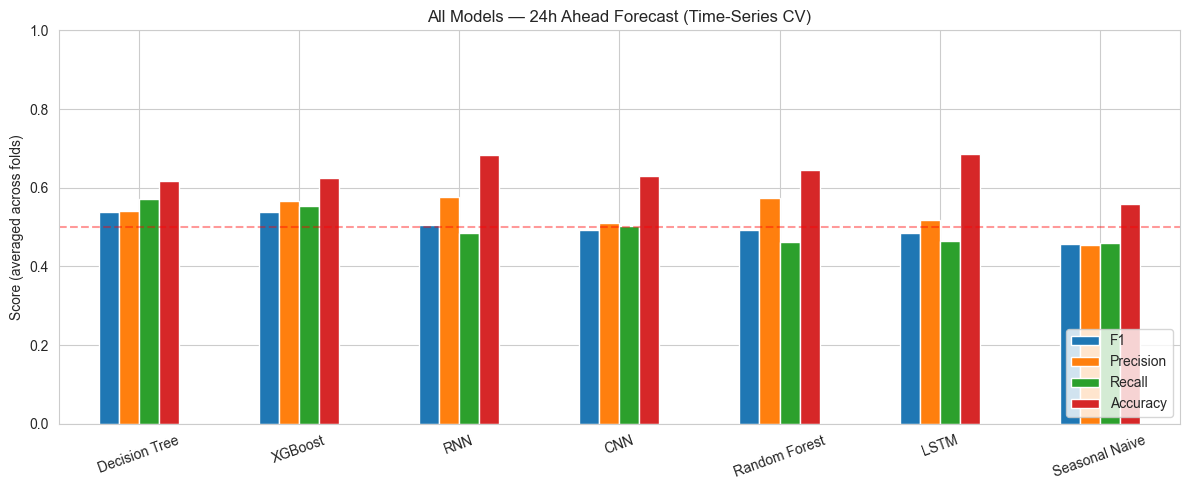

In [106]:
# ── 6. Merge with existing results and plot ───────────────────────────────────
nn_results_df = pd.DataFrame({
    name: {m: np.mean(v) for m, v in metrics.items()}
    for name, metrics in nn_metrics.items()
}).T

all_results_df = pd.concat([results_df, nn_results_df]).sort_values('F1', ascending=False)

print("\nFull model comparison:")
print(all_results_df.to_string(float_format='{:.3f}'.format))

all_results_df.plot(kind='bar', figsize=(12, 5), ylim=(0, 1), rot=20)
plt.title('All Models — 24h Ahead Forecast (Time-Series CV)')
plt.ylabel('Score (averaged across folds)')
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.4)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
def plot_tf_style_predictions(X_3D, y_3D, model, feature_index=0, num_plots=3):
    """
    Creates a stacked plot exactly like the TensorFlow Time Series tutorial.

    Parameters:
    X_3D: Your 3D testing features (Samples, Time_Steps, Features)
    y_3D: Your testing labels
    model: Your trained LSTM/CNN model
    feature_index: Which feature to draw the blue line for (e.g., 0 for PM2.5)
    num_plots: How many subplots to stack (the image has 3)
    """
    # 1. Get the model's predictions for the test set
    # Using > 0.5 to convert the probability back into a 1 or 0
    predictions = (model.predict(X_3D) > 0.5).astype(int)

    # 2. Set up the figure with multiple subplots stacked vertically
    fig, axes = plt.subplots(nrows=num_plots, ncols=1, figsize=(10, 8))

    # 3. Loop through to draw a few random examples from your test set
    # (We multiply by 100 just to space out the examples we pick)
    for i, ax in enumerate(axes):
        sample_idx = i * 100

        # Extract the sequence of inputs for the blue line
        inputs = X_3D[sample_idx, :, feature_index]
        input_time_steps = list(range(len(inputs)))

        # The label/prediction happens at the time step immediately after the inputs
        target_time = len(inputs)
        label = y_3D[sample_idx]
        prediction = predictions[sample_idx][0]

        # --- DRAWING THE TF STYLE PLOT ---

        # Plot 1: The Inputs (Blue line with dots)
        ax.plot(input_time_steps, inputs, label='Inputs', marker='.', zorder=-10)

        # Plot 2: The True Label (Green Circle with black edge)
        ax.scatter(target_time, label, edgecolors='k', label='Labels',
                   c='#2ca02c', s=64, zorder=2)

        # Plot 3: The Prediction (Orange X with black edge)
        ax.scatter(target_time, prediction, marker='X', edgecolors='k',
                   label='Predictions', c='#ff7f0e', s=64, zorder=3)

        # Formatting to match the tutorial
        ax.set_ylabel('Scaled Feature')
        if i == 0:
            ax.legend() # Only put the legend on the top plot

    # Add the x-axis label only to the very bottom plot
    axes[-1].set_xlabel('Time [h]')

    plt.tight_layout()
    plt.show()

# How to use it:
# (Assuming your scaled PM2.5 is at index 0 of your features)
# plot_tf_style_predictions(X_test_3D, y_test_3D, lstm_model, feature_index=0, num_plots=3)

# Overfitting

In [128]:
from tensorflow.keras.regularizers import l1, l2, l1_l2
from tensorflow.keras.layers import BatchNormalization


In [129]:
# ── Experiment variants ───────────────────────────────────────────────────────
def build_baseline():
    """Large network, no regularization — expected to overfit"""
    m = Sequential([
        LSTM(128, input_shape=(n_steps, n_features), return_sequences=True),
        LSTM(64),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

def build_reduced():
    """Smaller network — fewer parameters = less capacity to memorise"""
    m = Sequential([
        LSTM(32, input_shape=(n_steps, n_features)),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

def build_l1_l2():
    """Full size + L1/L2 weight penalties on LSTM kernel and recurrent kernel"""
    m = Sequential([
        LSTM(128, input_shape=(n_steps, n_features), return_sequences=True,
             kernel_regularizer=l1_l2(l1=1e-4, l2=1e-3),
             recurrent_regularizer=l2(1e-3)),
        LSTM(64,
             kernel_regularizer=l1_l2(l1=1e-4, l2=1e-3)),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

def build_dropout():
    """Full size + dropout on outputs and recurrent connections"""
    m = Sequential([
        LSTM(128, input_shape=(n_steps, n_features), return_sequences=True,
             dropout=0.3,              # drops input/output connections
             recurrent_dropout=0.2),   # drops recurrent connections
        LSTM(64,
             dropout=0.3,
             recurrent_dropout=0.2),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

In [130]:

variants = {
    'Baseline (no reg)': build_baseline,
    'Reduced Size':      build_reduced,
    'L1 + L2':           build_l1_l2,
    'Dropout':           build_dropout,
}

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


In [131]:
# ── Run experiment: one fold only for speed, use last fold for fair comparison ─
train_idx, test_idx = list(ts_cv.split(X_seq, y_seq))[-1]   # final fold
X_train_e, X_test_e = X_seq[train_idx], X_seq[test_idx]
y_train_e, y_test_e = y_seq[train_idx], y_seq[test_idx]

histories   = {}
exp_results = {}

for name, build_fn in variants.items():
    print(f"\nTraining: {name}")
    model = build_fn()

    history = model.fit(
        X_train_e, y_train_e,
        validation_split=0.15,
        epochs=60,
        batch_size=256,
        callbacks=[early_stop],
        verbose=0
    )
    histories[name] = history.history

    y_pred = (model.predict(X_test_e, verbose=0).flatten() > 0.5).astype(int)
    exp_results[name] = {
        'F1':        f1_score(y_test_e, y_pred),
        'Precision': precision_score(y_test_e, y_pred),
        'Recall':    recall_score(y_test_e, y_pred),
        'Accuracy':  accuracy_score(y_test_e, y_pred),
        'Best epoch': len(history.history['loss']),    # epochs before early stop
        'Train loss': min(history.history['loss']),
        'Val loss':   min(history.history['val_loss']),
    }



Training: Baseline (no reg)


/Users/darronporter/Downloads/COMP4030 Data Science & Machine Learning/Coursework/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training: Reduced Size


/Users/darronporter/Downloads/COMP4030 Data Science & Machine Learning/Coursework/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training: L1 + L2


/Users/darronporter/Downloads/COMP4030 Data Science & Machine Learning/Coursework/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training: Dropout


/Users/darronporter/Downloads/COMP4030 Data Science & Machine Learning/Coursework/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Overfitting Experiment Results:
                     F1  Precision  Recall  Accuracy  Best epoch  Train loss  Val loss
Baseline (no reg) 0.487      0.578   0.420     0.671       6.000       0.201     0.673
Reduced Size      0.459      0.544   0.396     0.653       7.000       0.343     0.623
L1 + L2           0.450      0.495   0.412     0.626       5.000       0.486     0.944
Dropout           0.430      0.543   0.356     0.650       5.000       0.523     0.638


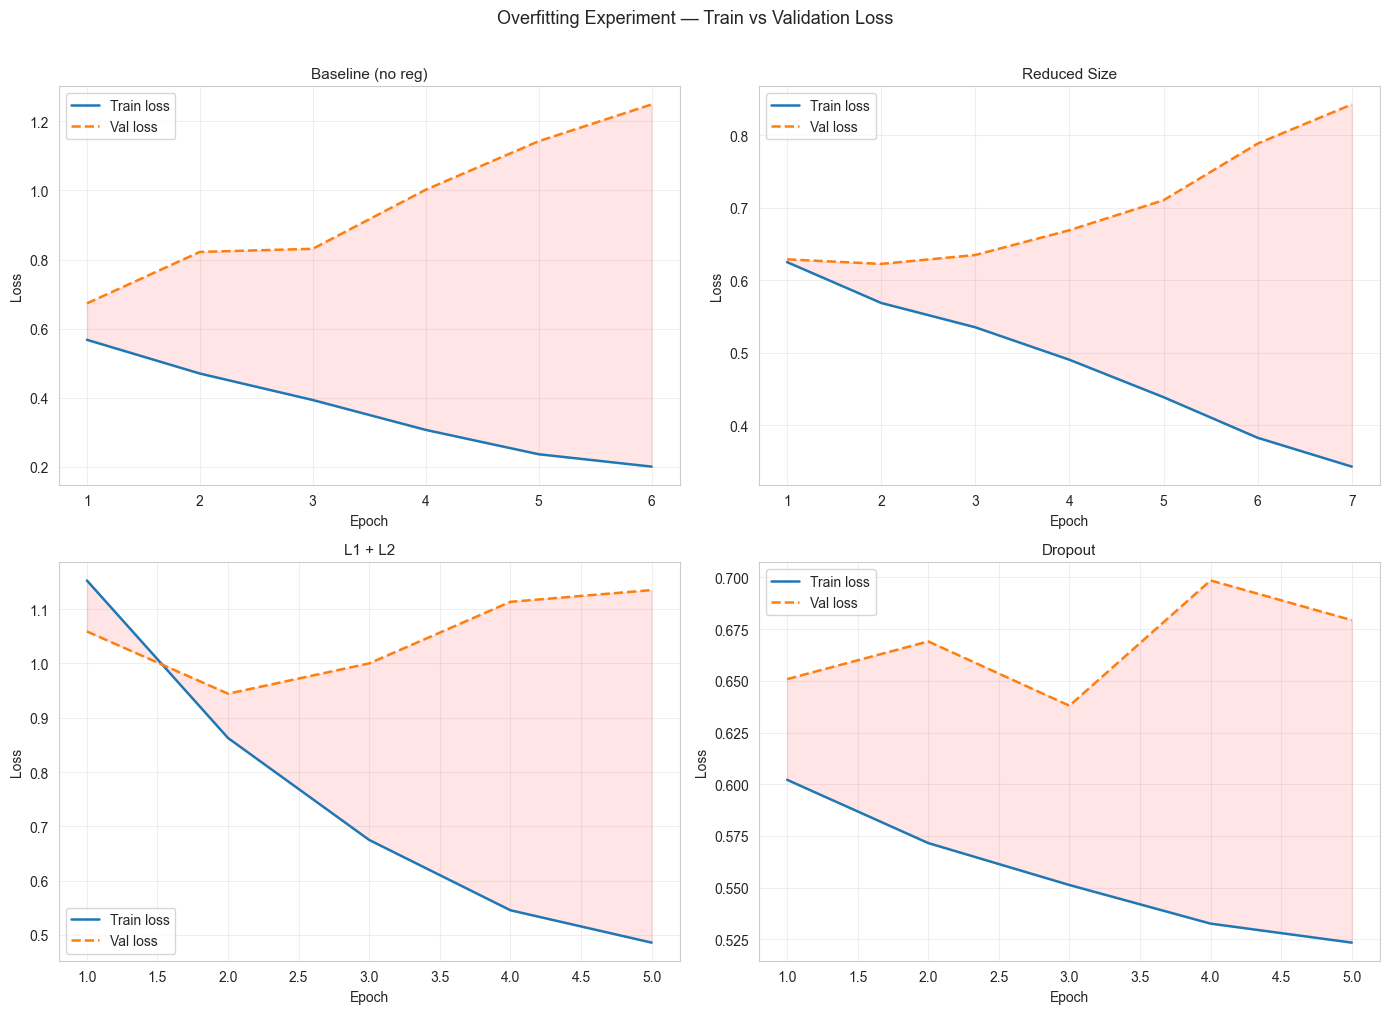

In [132]:
# ── Results table ─────────────────────────────────────────────────────────────
exp_df = pd.DataFrame(exp_results).T
print("\nOverfitting Experiment Results:")
print(exp_df.to_string(float_format='{:.3f}'.format))

# ── Plot 1: Train vs Val loss curves (overfitting diagnostic) ─────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, hist) in zip(axes, histories.items()):
    epochs = range(1, len(hist['loss']) + 1)
    ax.plot(epochs, hist['loss'],     label='Train loss', linewidth=1.8)
    ax.plot(epochs, hist['val_loss'], label='Val loss',   linewidth=1.8, linestyle='--')
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(alpha=0.3)

    # Highlight the gap between train and val (overfitting zone)
    ax.fill_between(epochs,
                    hist['loss'], hist['val_loss'],
                    alpha=0.1, color='red', label='Overfit gap')

plt.suptitle('Overfitting Experiment — Train vs Validation Loss', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


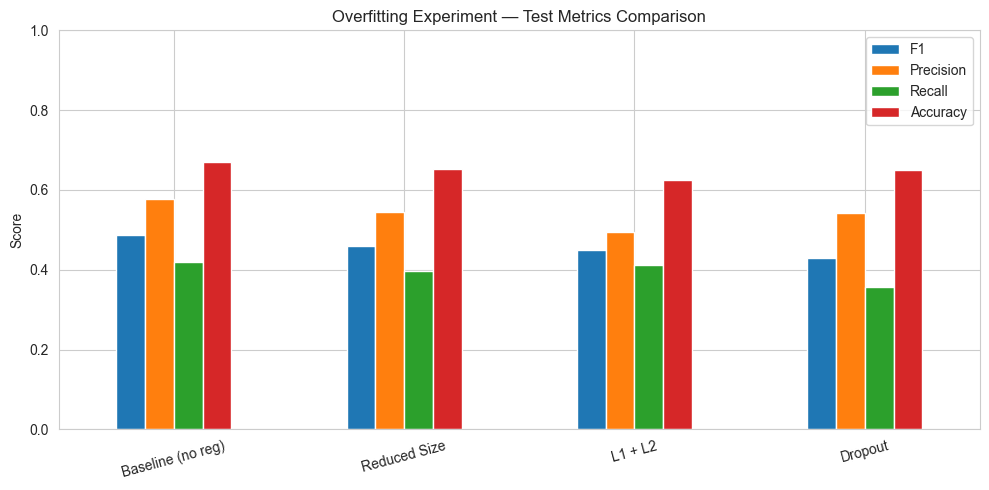

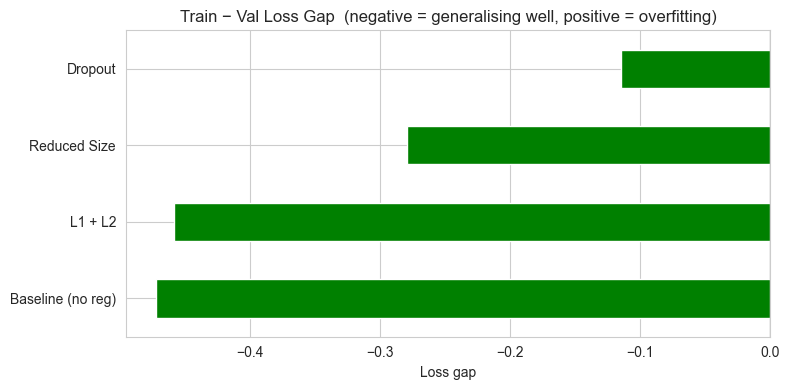

In [133]:
# ── Plot 2: F1 comparison bar chart ──────────────────────────────────────────
exp_df[['F1', 'Precision', 'Recall', 'Accuracy']].plot(
    kind='bar', figsize=(10, 5), ylim=(0, 1), rot=15
)
plt.title('Overfitting Experiment — Test Metrics Comparison')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

# ── Plot 3: Overfit gap bar (train loss − val loss per variant) ───────────────
gap = exp_df['Train loss'] - exp_df['Val loss']
gap.sort_values().plot(
    kind='barh', figsize=(8, 4),
    color=['green' if v <= 0 else 'tomato' for v in gap.sort_values()]
)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Train − Val Loss Gap  (negative = generalising well, positive = overfitting)')
plt.xlabel('Loss gap')
plt.tight_layout()
plt.show()

# Hyper-parameter Training & Selection